# Sequence Models

Sequence models as a versatile toolkit for any task where ordering, timing, or variable-length data matter, and previews that the course will make you comfortable applying them across this wide range of applications.

| Input (X)        | Output (Y)          | Sequence?                 | Typical Task               |
| ---------------- | ------------------- | ------------------------- | -------------------------- |
| Audio clip       | Text transcript     | X & Y                     | Speech recognition         |
| — / genre tag    | Notes stream        | Y only                    | Music generation           |
| Review text      | Rating (stars)      | X only                    | Sentiment classification   |
| DNA string       | Protein labels      | X only                    | Genomics / DNA annotation  |
| Foreign sentence | Translated sentence | X & Y (different lengths) | Machine translation        |
| Video frames     | Activity label      | X & Y (same length)       | Video activity recognition |
| Sentence         | Named entities      | X & Y (same length)       | Named-entity recognition   |

Variety of sequence problems:

Sometimes both X and Y are sequences (and may differ in length).
Sometimes only one of them is a sequence.


### Summary of the Video on Sequence Model Notation & Word Representation


#### 🔁 **Motivating Example: Named Entity Recognition (NER)**

* Input: A sentence like *"Harry Potter and Hermione Granger invented a new spell."*
* Output: For each word, indicate whether it's part of a **person’s name**.
* This is a **sequence-to-sequence** problem: both input (X) and output (Y) are sequences of the same length.

---

#### 🧾 **Sequence Notation Setup**

* **Words in sentence**: Represented as $x^{\langle 1 \rangle}, x^{\langle 2 \rangle}, \ldots, x^{\langle T_x \rangle}$
* **Outputs**: $y^{\langle 1 \rangle}, y^{\langle 2 \rangle}, \ldots, y^{\langle T_y \rangle}$
* $T_x$: Length of input sequence
* $T_y$: Length of output sequence

  * In NER, $T_x = T_y$, but in general they can differ (e.g., in translation)
* For training data:

  * $x^{(i)\langle t \rangle}$: t-th input word of the i-th training example
  * $y^{(i)\langle t \rangle}$: corresponding output

---

#### 📚 **Vocabulary and One-Hot Encoding**

* Define a **dictionary (vocabulary)** of most common words (e.g., 10,000 words).
* Each word is represented by a **one-hot vector** of size 10,000:

  * Only the position corresponding to the word’s index in the dictionary is 1; all else are 0.
  * Example:

    * “Harry” at position 4075 → vector with 1 at index 4075
    * “Potter” at 6830 → vector with 1 at index 6830
* So, each $x_t$ becomes a one-hot vector, and the sentence becomes a sequence of such vectors.

---

#### ❓ **Out-of-Vocabulary Words**

* Words not in the dictionary are represented by a special token: **UNK** (unknown).

---

### ✅ **In Summary**

* Introduced **notations** for handling variable-length input and output sequences in training.
* Explained how to **represent words using one-hot vectors** from a predefined vocabulary.
* Mentioned handling **unknown words** with an `UNK` token.
* Prepares the ground for the next topic: **Recurrent Neural Networks (RNNs)** to map from $X \rightarrow Y$.

---

This video builds the notational and representational framework needed to begin implementing sequence models like RNNs in NLP tasks.


### RNN ( Recurrent Neural Network)

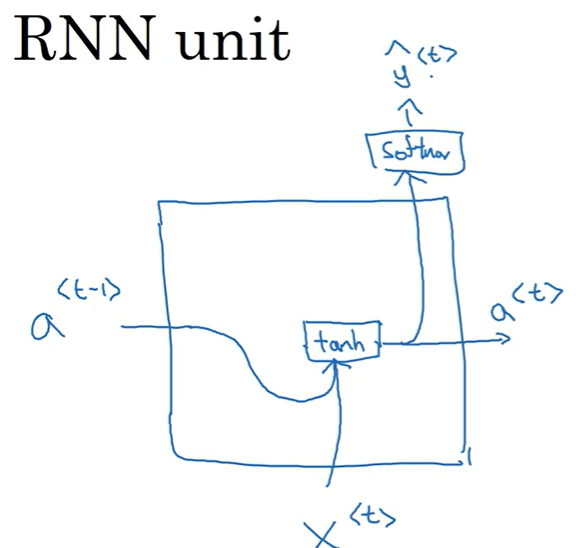

How are words represented ? 

The words are represented mathematically using **vector representations**. There are two main ways this is done, depending on the stage of the model:

---

### 🔹 1. **One-Hot Encoding (basic, used in earlier examples)**

* You define a **vocabulary** of size $V$ (e.g., 10,000 words).
* Each word is assigned a **unique index** in that vocabulary.

Suppose:

* "Harry" is at index **4075** in the vocabulary of 10,000 words.

Then:

* **"Harry"** is represented as a **10,000-dimensional vector** $x$, where:

  * All entries are **0**, except the **4075th** entry which is **1**.

Mathematically:

$$
x^{\langle t \rangle} = \begin{bmatrix}0 \\ 0 \\ \vdots \\ \underset{4075\text{th}}{1} \\ \vdots \\ 0\end{bmatrix} \in \mathbb{R}^{10000}
$$

This is called a **one-hot vector**.

---

### 🔹 2. **Word Embedding (more efficient and meaningful)**

In practice, one-hot vectors are passed through an **embedding layer**, which maps them to a **dense, low-dimensional vector** (e.g., 300D or 512D) that captures semantic meaning.

So:

$$
\text{Embedding matrix } E \in \mathbb{R}^{d \times V}
$$

Where:

* $V$: vocabulary size (e.g., 10,000)
* $d$: embedding dimension (e.g., 300)

To get the embedding for "Harry":

* Multiply the embedding matrix $E$ with the one-hot vector $x_{\text{Harry}}$:

$$
v_{\text{Harry}} = E \cdot x_{\text{Harry}} \in \mathbb{R}^d
$$

Since $x_{\text{Harry}}$ is one-hot, this just selects the 4075th column of $E$.

Result:

* $v_{\text{Harry}}$: dense vector like

$$
[0.21, -0.08, 0.35, \dots, -0.14] \in \mathbb{R}^{300}
$$

This dense vector is what is typically **fed into the RNN**.

---

### ✅ Summary

| Representation | Dimension        | Description                                       |
| -------------- | ---------------- | ------------------------------------------------- |
| **One-hot**    | $\mathbb{R}^{V}$ | Vector with 1 at index of "Harry", 0 elsewhere    |
| **Embedding**  | $\mathbb{R}^{d}$ | Dense vector capturing "Harry"'s semantic meaning |

Let me know if you'd like to see how this fits into forward propagation in RNNs.


### Summary: Building a Basic Recurrent Neural Network (RNN)

This video explains **why standard neural networks fail for sequences**, introduces **Recurrent Neural Networks (RNNs)** as a solution, and outlines **how forward propagation works in RNNs**.

---

### 🚫 Limitations of Standard Neural Networks for Sequence Tasks

1. **Variable-length input/output**

   * Real-world examples (e.g., sentences) have different lengths. Standard feedforward networks expect fixed input/output sizes.

2. **No parameter sharing across time steps**

   * A traditional NN doesn't learn that a word like “Harry” in position 1 is similar to “Harry” in position 5.
   * RNNs share parameters across time, enabling learning across positions and reducing total parameters.

---

### 🔁 What is a Recurrent Neural Network (RNN)?

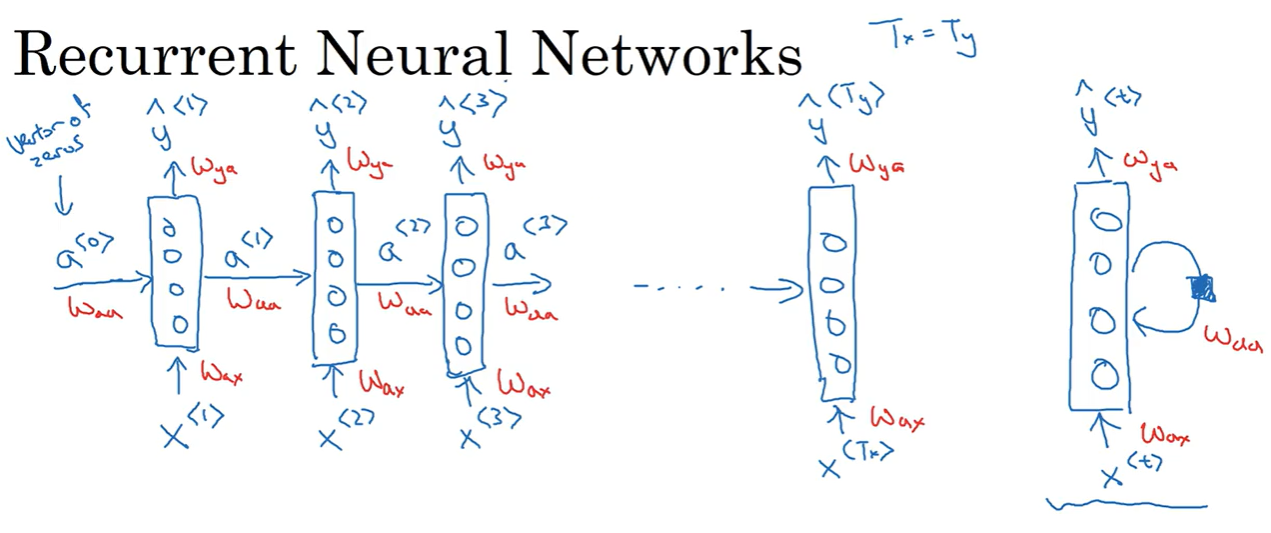

* RNN processes input **sequentially, one step at a time**.

* At each time step $t$, RNN:

  * Takes current input $x^{\langle t \rangle}$
  * Takes previous hidden state $a^{\langle t-1 \rangle}$
  * Outputs:

    * Updated hidden state $a^{\langle t \rangle}$
    * Prediction $\hat{y}^{\langle t \rangle}$

* **Initial hidden state** $a^{\langle 0 \rangle}$: Typically a zero vector.

---

### 🧠 RNN Parameter Sharing

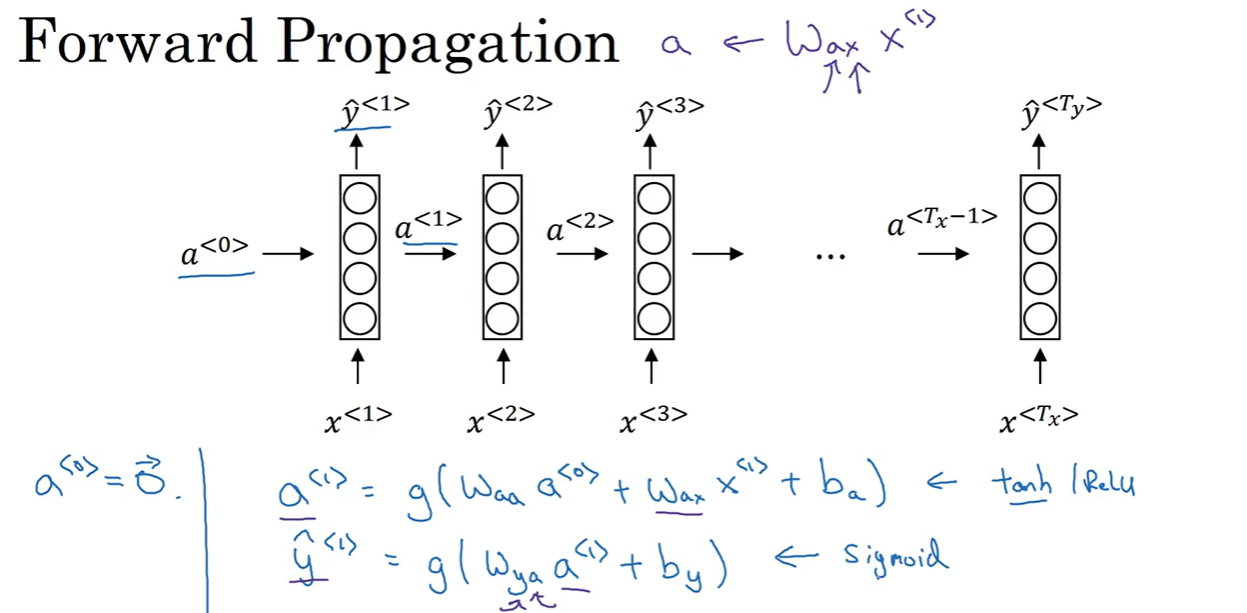

* Parameters shared across time steps:

  * $W_{ax}$: from input to hidden state
  * $W_{aa}$: from previous hidden state to current
  * $W_{ya}$: from hidden state to output
* Same weights used for all steps $t = 1, 2, ..., T_x$

---

### 🔄 Forward Propagation Equations

At time step $t$:

$$
a^{\langle t \rangle} = g(W_{aa} a^{\langle t-1 \rangle} + W_{ax} x^{\langle t \rangle} + b_a)
$$

$$
\hat{y}^{\langle t \rangle} = g'(W_{ya} a^{\langle t \rangle} + b_y)
$$

* $g$: usually **tanh** for hidden layer
* $g'$: depends on output type (e.g., **sigmoid** for binary classification)

---

### 🧮 Simplified Notation

To reduce complexity, define:

* Concatenated vector:

  $$
  [a^{\langle t-1 \rangle}, x^{\langle t \rangle}]
  $$
* Concatenated weight matrix:

  $$
  W_a = [W_{aa}, W_{ax}]
  $$

Then, forward pass becomes:

$$
a^{\langle t \rangle} = g(W_a \cdot [a^{\langle t-1 \rangle}, x^{\langle t \rangle}] + b_a)
$$

$$
\hat{y}^{\langle t \rangle} = g'(W_y a^{\langle t \rangle} + b_y)
$$

---

### 📉 Limitation: Only Past Context Used

* Standard (unidirectional) RNN only uses **past context**.
* Doesn’t consider **future words** — limits understanding in tasks like name recognition (e.g., “Teddy” might need future context).
* **Solution**: Covered later using **Bidirectional RNNs (BRNNs)**.

---

### ✅ In Summary

* Standard NNs don’t work well for sequence data → Enter RNNs.
* RNNs handle variable-length sequences and **share parameters** across time steps.
* RNN maintains a **hidden state** that carries forward temporal information.
* Forward propagation combines previous hidden state and current input using shared weights.
* Simplified notation helps generalize to more complex RNNs in future lessons.


#### Backpropagation 

### Backpropagation in Recurrent Neural Networks (RNNs)

---

### 🔁 **Forward Propagation Recap**

1. Given input sequence $x_1, x_2, \dots, x_{T_x}$
2. Use hidden state recurrence:

   $$
   a^{\langle t \rangle} = g(W_{aa} a^{\langle t-1 \rangle} + W_{ax} x^{\langle t \rangle} + b_a)
   $$
3. Predict outputs:

   $$
   \hat{y}^{\langle t \rangle} = g'(W_{ya} a^{\langle t \rangle} + b_y)
   $$
4. Repeat this **left to right**, across all $t \in [1, T_x]$

---

### 📉 **Loss Function**

* Use standard **cross-entropy loss** at each time step:

  $$
  \mathcal{L}^{\langle t \rangle} = - \left( y^{\langle t \rangle} \log(\hat{y}^{\langle t \rangle}) + (1 - y^{\langle t \rangle}) \log(1 - \hat{y}^{\langle t \rangle}) \right)
  $$
* **Total sequence loss** is the sum over all time steps:

  $$
  \mathcal{L} = \sum_{t=1}^{T_x} \mathcal{L}^{\langle t \rangle}
  $$

---

### 🔙 **Backpropagation Through Time (BPTT)**

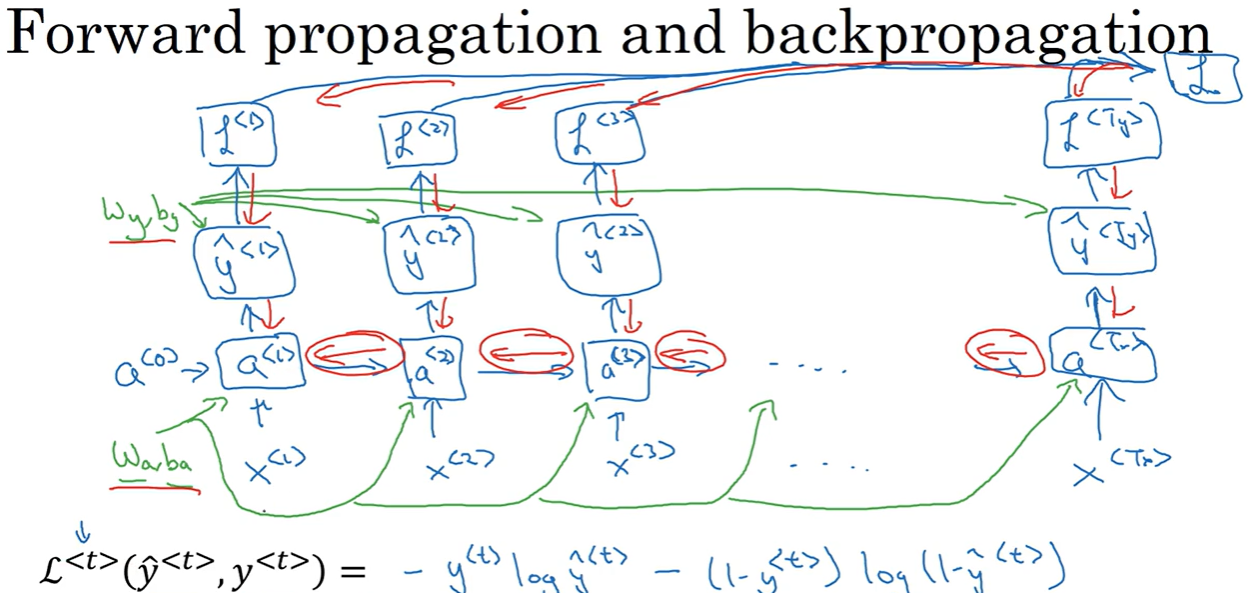

* Perform **backward pass from last time step to first**:

  * Gradients flow through both:

    * Time (past activations $a^{\langle t \rangle}$)
    * Parameters (shared weights: $W_{aa}, W_{ax}, W_{ya}$)

* Since the same parameters are used at every step, the **gradients from all steps are accumulated** before updating:

  $$
  \frac{\partial \mathcal{L}}{\partial W_{ax}} = \sum_{t=1}^{T_x} \frac{\partial \mathcal{L}^{\langle t \rangle}}{\partial W_{ax}} \quad \text{(and similarly for other weights)}
  $$

---

### ⏪ Why It's Called “Backpropagation Through Time”

* Forward pass: moves **forward in time** → $t = 1 \to T_x$
* Backward pass: moves **backward in time** → $t = T_x \to 1$
* Hence, the name: **Backpropagation Through Time (BPTT)**
  (like you're computing gradients by "traveling back in time")

---

### ✅ Key Takeaways

* Backpropagation in RNNs = standard backprop + handling **temporal recurrence**.
* Uses the same parameter set at each time step → gradients accumulate over time.
* BPTT enables learning from sequences by propagating error signals **backward across time**.
* This example used $T_x = T_y$, but upcoming videos will handle more varied architectures like:

  * Different input/output lengths
  * Sequence-to-single
  * Sequence-to-sequence

---

This sets the stage for deeper architectures and real-world RNN applications. Let me know if you'd like a visual or equations breakdown of how gradients flow over time.


#### Types of RNN 

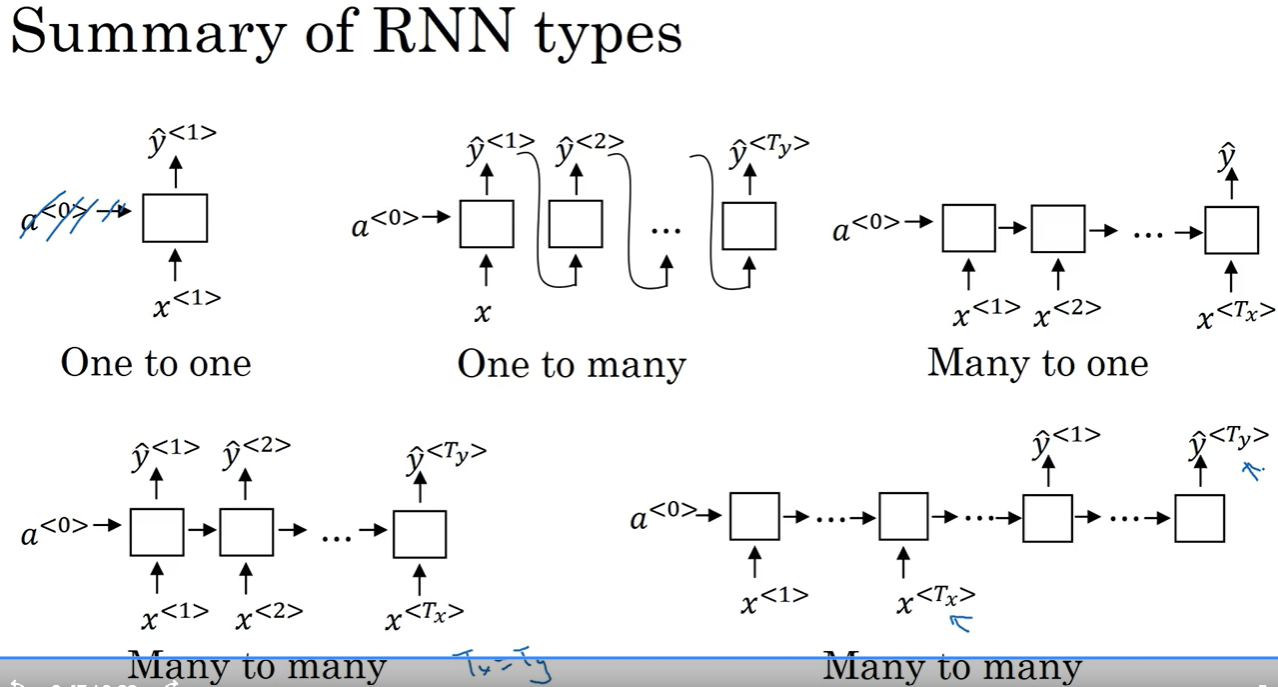

### 🧠 Summary: Language Modeling with RNNs

This video introduces **language modeling** as a key task in NLP and shows how to build a **Recurrent Neural Network (RNN)** to model natural language.

---

### 📖 What is a Language Model?

* A **language model** assigns a **probability to a sequence of words**.
* Example: Speech recognition system chooses the more likely sentence between:

  * *"The apple and pair salad..."* (low probability)
  * *"The apple and pear salad..."* (high probability)
* Language models help systems like:

  * ✅ Speech recognition
  * ✅ Machine translation
  * ✅ Text generation

---

### 🏗️ How to Build a Language Model with an RNN

#### 1. **Training Data Preparation**

* Use a **corpus** (large collection of sentences).
* Example sentence: *"Cats average 15 hours of sleep a day."*
* Tokenize the sentence into words:

  * Map each word to an index (or one-hot vector) from the vocabulary.
  * Optionally add an **EOS (end-of-sentence)** token.
  * Handle unknown words using a special **UNK** token.

#### 2. **RNN Setup**

* Let the RNN **predict the next word** given previous words.
* At each time step $t$:

  * Input: $x^{\langle t \rangle} = y^{\langle t-1 \rangle}$ (previous word)
  * Output: $\hat{y}^{\langle t \rangle}$ = probability distribution over vocabulary
  * Use **Softmax** to get probabilities

Example:

* Time step 1: Input = <zero vector>, output = $\hat{y}^{\langle 1 \rangle}$ = prob(word is "Cats")
* Time step 2: Input = "Cats", output = prob(word is "average")
* Time step 3: Input = "average", output = prob(word is "15")
* ...
* Time step 9: Input = "day", output = prob(EOS)

---

### 🧮 Cost Function

* Use **Softmax + cross-entropy loss** at each time step.
* Total loss = sum of losses over all time steps:

  $$
  \mathcal{L} = \sum_{t=1}^{T_y} \text{loss}(y^{\langle t \rangle}, \hat{y}^{\langle t \rangle})
  $$

---

### 🎯 Purpose of the Language Model

After training:

* The RNN can predict the **probability of the next word** given previous context.
* For a sentence $y^{\langle 1 \rangle}, y^{\langle 2 \rangle}, ..., y^{\langle T \rangle}$:

  $$
  P(y^{\langle 1 \rangle}, y^{\langle 2 \rangle}, ..., y^{\langle T \rangle}) = P(y^{\langle 1 \rangle}) \cdot P(y^{\langle 2 \rangle} \mid y^{\langle 1 \rangle}) \cdot P(y^{\langle 3 \rangle} \mid y^{\langle 1 \rangle}, y^{\langle 2 \rangle}) \cdots
  $$


### ✅ Key Takeaways

| Concept                | Description                                                    |
| ---------------------- | -------------------------------------------------------------- |
| **Language model**     | Assigns probability to a word sequence                         |
| **Input at time $t$**  | Previous word $y^{\langle t-1 \rangle}$                        |
| **Output at time $t$** | Prob. distribution over vocabulary for $y^{\langle t \rangle}$ |
| **Loss**               | Cross-entropy at each time step                                |
| **Training goal**      | Maximize probability of correct next word at each step         |


### 🧠 Summary: Language Modeling with RNNs

---

### 📖 What is a Language Model?

* A **language model** assigns a **probability to a sequence of words**.
* Example: Speech recognition system chooses the more likely sentence between:

  * *"The apple and pair salad..."* (low probability)
  * *"The apple and pear salad..."* (high probability)
* Language models help systems like:

  * ✅ Speech recognition
  * ✅ Machine translation
  * ✅ Text generation

---

### 🏗️ How to Build a Language Model with an RNN

#### 1. **Training Data Preparation**

* Use a **corpus** (large collection of sentences).
* Example sentence: *"Cats average 15 hours of sleep a day."*
* Tokenize the sentence into words:

  * Map each word to an index (or one-hot vector) from the vocabulary.
  * Optionally add an **EOS (end-of-sentence)** token.
  * Handle unknown words using a special **UNK** token.

#### 2. **RNN Setup**

* Let the RNN **predict the next word** given previous words.
* At each time step $t$:

  * Input: $x^{\langle t \rangle} = y^{\langle t-1 \rangle}$ (previous word)
  * Output: $\hat{y}^{\langle t \rangle}$ = probability distribution over vocabulary
  * Use **Softmax** to get probabilities

Example:

* Time step 1: Input = <zero vector>, output = $\hat{y}^{\langle 1 \rangle}$ = prob(word is "Cats")
* Time step 2: Input = "Cats", output = prob(word is "average")
* Time step 3: Input = "average", output = prob(word is "15")
* ...
* Time step 9: Input = "day", output = prob(EOS)

---

### 🧮 Cost Function

* Use **Softmax + cross-entropy loss** at each time step.
* Total loss = sum of losses over all time steps:

  $$
  \mathcal{L} = \sum_{t=1}^{T_y} \text{loss}(y^{\langle t \rangle}, \hat{y}^{\langle t \rangle})
  $$

---

### 🎯 Purpose of the Language Model

After training:

* The RNN can predict the **probability of the next word** given previous context.
* For a sentence $y^{\langle 1 \rangle}, y^{\langle 2 \rangle}, ..., y^{\langle T \rangle}$:

  $$
  P(y^{\langle 1 \rangle}, y^{\langle 2 \rangle}, ..., y^{\langle T \rangle}) = P(y^{\langle 1 \rangle}) \cdot P(y^{\langle 2 \rangle} \mid y^{\langle 1 \rangle}) \cdot P(y^{\langle 3 \rangle} \mid y^{\langle 1 \rangle}, y^{\langle 2 \rangle}) \cdots
  $$

#### Training example 

Great question! Let's walk through how the RNN **trains** on the sentence:

> **"Cat is an animal"**

This explanation will cover:

1. **Tokenization and Vocabulary**
2. **Input-Output Preparation for Language Modeling**
3. **Forward Propagation Step-by-Step**
4. **Loss Computation**
5. **Backpropagation Through Time (BPTT)**

---

## 🧾 1. Tokenization and Vocabulary

Assume we build a vocabulary of common words and assign an index to each:

| Word     | Index |
| -------- | ----- |
| `<UNK>`  | 0     |
| `<EOS>`  | 1     |
| `Cat`    | 2     |
| `is`     | 3     |
| `an`     | 4     |
| `animal` | 5     |

We tokenize the sentence:

```text
"Cat is an animal" → ["Cat", "is", "an", "animal", <EOS>]
```

So the **sequence becomes**:

```text
y¹ = Cat, y² = is, y³ = an, y⁴ = animal, y⁵ = <EOS>
```

---

## 📥 2. Input-Output Pairs for Language Modeling

In **language modeling**, the goal is to **predict the next word given previous ones**. So the model will learn:

| Input (xᵗ)      | Target (yᵗ) |
| --------------- | ----------- |
| `<zero vector>` | `Cat`       |
| `Cat`           | `is`        |
| `is`            | `an`        |
| `an`            | `animal`    |
| `animal`        | `<EOS>`     |

Note:

* $x^{\langle t \rangle} = y^{\langle t-1 \rangle}$
* $x^{\langle 1 \rangle}$ is a **zero vector** or special token to start

---

## 🔁 3. Forward Propagation Through RNN

At each time step $t$, the RNN performs:

### Hidden state update:

$$
a^{\langle t \rangle} = \tanh(W_{aa} \cdot a^{\langle t-1 \rangle} + W_{ax} \cdot x^{\langle t \rangle} + b_a)
$$

### Output prediction:

$$
\hat{y}^{\langle t \rangle} = \text{softmax}(W_{ya} \cdot a^{\langle t \rangle} + b_y)
$$

Example for your sentence:

| Step $t$ | $x^{\langle t \rangle}$ | $a^{\langle t \rangle}$ | $\hat{y}^{\langle t \rangle}$ (Predicted word) |
| -------- | ----------------------- | ----------------------- | ---------------------------------------------- |
| 1        | `<zero vector>`         | $a^{\langle 1 \rangle}$ | prob distribution over vocabulary for "Cat"    |
| 2        | one-hot for "Cat"       | $a^{\langle 2 \rangle}$ | prob distribution for "is"                     |
| 3        | one-hot for "is"        | $a^{\langle 3 \rangle}$ | prob for "an"                                  |
| 4        | one-hot for "an"        | $a^{\langle 4 \rangle}$ | prob for "animal"                              |
| 5        | one-hot for "animal"    | $a^{\langle 5 \rangle}$ | prob for `<EOS>`                               |

---

## 📉 4. Loss Computation

At each step, we use **cross-entropy loss** between prediction $\hat{y}^{\langle t \rangle}$ and the actual word $y^{\langle t \rangle}$.

Total loss:

$$
\mathcal{L} = \sum_{t=1}^{5} \text{cross\_entropy}(y^{\langle t \rangle}, \hat{y}^{\langle t \rangle})
$$

Great! Let’s **zoom in on Step 4 (Loss Computation)** specifically for:

* **Step 1**: Predicting "Cat" given a zero input
* **Step 3**: Predicting "an" given the previous word "is"

We’ll go through:

1. The Softmax prediction $\hat{y}^{\langle t \rangle}$
2. The actual (true) target $y^{\langle t \rangle}$
3. The Cross-Entropy Loss calculation

---
Example
---

## 🔹 Step 1 — Predicting “Cat” ( $t = 1$ )

### 📥 Input:

* $x^{\langle 1 \rangle}$ = `<zero vector>`
* $a^{\langle 0 \rangle}$ = `<zero vector>`

### 🧠 Hidden state:

$$
a^{\langle 1 \rangle} = \tanh(W_{aa} a^{\langle 0 \rangle} + W_{ax} x^{\langle 1 \rangle} + b_a)
$$

Since both $a^{\langle 0 \rangle}$ and $x^{\langle 1 \rangle}$ are zero, this simplifies to:

$$
a^{\langle 1 \rangle} = \tanh(b_a)
$$

### 📤 Output prediction:

$$
\hat{y}^{\langle 1 \rangle} = \text{softmax}(W_{ya} a^{\langle 1 \rangle} + b_y)
$$

This produces a **probability distribution over the vocabulary**. Let’s say the vocabulary has 6 tokens:

```
[UNK, EOS, Cat, is, an, animal]
```

Suppose the model outputs:

```
\hat{y}^{⟨1⟩} = [0.01, 0.01, 0.80, 0.10, 0.05, 0.03]
```

* i.e., the model assigns **80% probability** to "Cat"

### ✅ Ground truth:

* Actual next word is "Cat" → one-hot: `[0, 0, 1, 0, 0, 0]`

### 📉 Cross-entropy loss:

$$
\mathcal{L}^{\langle 1 \rangle} = -\log(\hat{y}^{\langle 1 \rangle}_{\text{true index}})
= -\log(0.80) \approx 0.223
$$

---

## 🔹 Step 3 — Predicting “an” ( $t = 3$ )

### 📥 Input:

* $x^{\langle 3 \rangle}$ = one-hot for "is" = `[0, 0, 0, 1, 0, 0]`
* $a^{\langle 2 \rangle}$ from previous step

### 🧠 Hidden state:

$$
a^{\langle 3 \rangle} = \tanh(W_{aa} a^{\langle 2 \rangle} + W_{ax} x^{\langle 3 \rangle} + b_a)
$$

### 📤 Output prediction:

$$
\hat{y}^{\langle 3 \rangle} = \text{softmax}(W_{ya} a^{\langle 3 \rangle} + b_y)
$$

Suppose it gives:

```
\hat{y}^{⟨3⟩} = [0.01, 0.01, 0.05, 0.10, 0.80, 0.03]
```

* i.e., model assigns **80% probability** to "an"

### ✅ Ground truth:

* Actual next word is "an" → one-hot: `[0, 0, 0, 0, 1, 0]`

### 📉 Cross-entropy loss:

$$
\mathcal{L}^{\langle 3 \rangle} = -\log(0.80) \approx 0.223
$$

---

## 🧮 Total Loss (partial)

If we just consider steps 1 and 3:

$$
\mathcal{L}_{\text{partial}} = \mathcal{L}^{\langle 1 \rangle} + \mathcal{L}^{\langle 3 \rangle} \approx 0.223 + 0.223 = 0.446
$$




---

## 🔄 5. Backpropagation Through Time (BPTT)

* Compute **gradients** of the total loss $\mathcal{L}$ w\.r.t all parameters:

  * $W_{aa}, W_{ax}, W_{ya}, b_a, b_y$
* Gradient is **accumulated across all time steps**, considering how earlier time steps influence later outputs.
* **Update weights** using gradient descent (or Adam, etc.)

---

## ✅ Final Output After Training

After training on many sentences, including "Cat is an animal", the model learns that:

* After "Cat", "is" is likely
* After "is", "an" is likely
* etc.

At inference time, if you input:

```text
"Cat is an"
```

The RNN will output a distribution with high probability on:

```text
"animal"
```


### Sampling from an RNN Language Model

After training an RNN-based language model, you can **sample novel sentences** from it to get a sense of what the model has learned. Here's a breakdown of how it works:

### 🧾 1. **How the Model Generates Text**

The trained RNN models the probability of a sequence:

$$
P(y^{\langle 1 \rangle}, y^{\langle 2 \rangle}, ..., y^{\langle T \rangle})
$$

To **generate text**:

#### Step-by-step:

1. **Start with**:

   * Initial hidden state $a^{\langle 0 \rangle} = 0$
   * Input $x^{\langle 1 \rangle} = 0$ or special start token

2. **At each time step $t$**:

   * Compute hidden state:

     $$
     a^{\langle t \rangle} = \tanh(W_{aa} a^{\langle t-1 \rangle} + W_{ax} x^{\langle t \rangle} + b_a)
     $$
   * Predict output distribution:

     $$
     \hat{y}^{\langle t \rangle} = \text{softmax}(W_{ya} a^{\langle t \rangle} + b_y)
     $$
   * **Sample a word** from this distribution using a function like `np.random.choice`

3. **Feed the sampled word** back into the next time step as $x^{\langle t+1 \rangle}$

4. **Repeat** until:

   * An **<EOS> token** is sampled (if used), or
   * A fixed number of words are generated

#### Handling `<UNK>` (Unknown Word):

* You may allow it, or
* Reject and resample until a known word is chosen


### 🅰️ 2. Word-Level vs. Character-Level Language Models

#### 🔤 **Character-level LM**:

* Vocabulary = characters (a–z, A–Z, space, punctuation, digits)
* Sequence is processed character by character

**Advantages**:

* No `<UNK>` token needed — can generate any word
* Useful for rare or morphologically complex languages

**Disadvantages**:

* Sequences are much longer (e.g., 50+ time steps per sentence)
* Harder to learn **long-range dependencies**
* More **computationally expensive**

#### 🧾 **Word-level LM**:

* Vocabulary = most common words in training data
* Sequences are shorter (e.g., 10–20 words per sentence)
* Better at modeling sentence structure and grammar
* Still standard in many NLP applications


### The Vanishing Gradient Problem in RNNs

There is a **critical limitation** of basic Recurrent Neural Networks (RNNs): their inability to **learn long-term dependencies** due to the **vanishing gradient problem**. Here's the breakdown:


### ❌ Problem: Vanishing Gradients

#### 🔍 Real-world example:

* Sentence: *"The cat, which already ate... was full."*
* The model needs to **remember "cat" (singular)** to decide between *"was"* vs *"were"*
* The gap between "cat" and "was" may be **dozens of time steps**
* Basic RNNs **struggle to retain** such distant information

---

### 📉 Why This Happens

* Training RNNs = training **very deep networks** (e.g., 1,000+ "layers" = time steps)
* Just like deep feedforward nets, RNNs suffer from:

  * **Vanishing gradients**: gradients shrink exponentially → early layers barely get updated
  * **Exploding gradients**: gradients blow up exponentially → instability, NaNs

#### 🔁 In RNNs:

* **Forward pass**: left to right
* **Backpropagation**: right to left
* Gradients **decay** (vanish) as they propagate to early time steps
  → Model focuses only on **local** patterns

---

### 💥 Exploding Gradients: Easier to Fix

* Symptoms:

  * Parameters become huge
  * NaNs in training
* ✅ Solution: **Gradient Clipping**

  $$
  \text{if } \|\nabla \theta\| > \tau \Rightarrow \nabla \theta := \tau \cdot \frac{\nabla \theta}{\|\nabla \theta\|}
  $$

---

### 🚫 Vanishing Gradients: Much Harder to Fix

* Hard to train models that require **long-term memory**
* Cannot propagate important signals **back in time**
* Makes RNNs bad at tasks like:

  * Subject-verb agreement over long gaps
  * Context-dependent word prediction


#### Gated Recurrent Unit ( GRU)

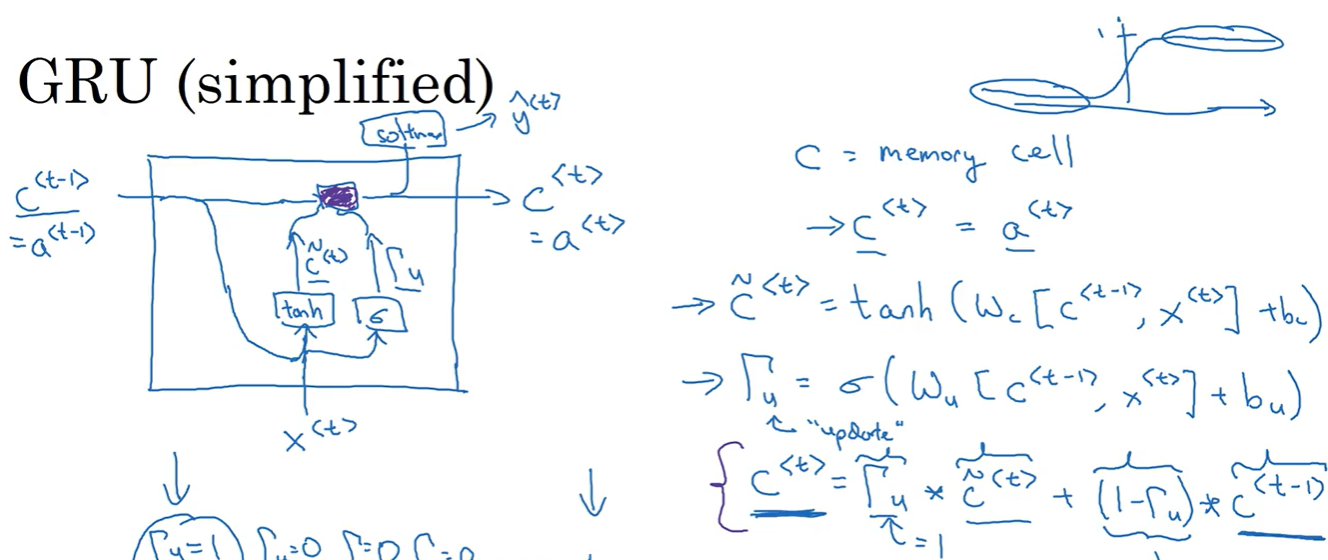

### Gated Recurrent Unit (GRU) — Solving Vanishing Gradients in RNNs

---

### 🔁 Motivation

Basic RNNs struggle with **long-range dependencies** due to the **vanishing gradient problem**. GRUs (Gated Recurrent Units) are designed to fix this by introducing **gates** that control how information is updated and retained across time steps.

---

### 🔐 GRU Key Concepts

#### 🔸 Memory Cell

* New variable: `cᵗ` (cell state) = memory
* In GRUs, the cell state **is equal to the hidden state** `aᵗ`:

  $$
  c^{\langle t \rangle} = a^{\langle t \rangle}
  $$

#### 🔸 Candidate Cell State

* Proposed new memory value:

  $$
  \tilde{c}^{\langle t \rangle} = \tanh(W_c[\gamma_r * a^{\langle t-1 \rangle}, x^{\langle t \rangle}] + b_c)
  $$

#### 🔸 Gates

1. **Update Gate (γᵤ)**:
   Decides **how much of the new value** to write:

   $$
   \gamma_u = \sigma(W_u [a^{\langle t-1 \rangle}, x^{\langle t \rangle}] + b_u)
   $$

2. **Relevance (Reset) Gate (γᵣ)**:
   Controls **how much past info to use** for candidate cell state:

   $$
   \gamma_r = \sigma(W_r [a^{\langle t-1 \rangle}, x^{\langle t \rangle}] + b_r)
   $$

---

### 🔁 GRU Update Rule

Update memory (`cᵗ`), hence hidden state (`aᵗ`), as a mix of new and old:

$$
c^{\langle t \rangle} = \gamma_u * \tilde{c}^{\langle t \rangle} + (1 - \gamma_u) * c^{\langle t-1 \rangle}
$$

* If `γᵤ ≈ 1` → **Overwrite** memory with candidate
* If `γᵤ ≈ 0` → **Keep** old memory (carry it forward)

---

### ✅ Benefits of GRU

| Feature                        | Benefit                                            |
| ------------------------------ | -------------------------------------------------- |
| **Update Gate γᵤ**             | Learns **when to write** to memory                 |
| **Reset Gate γᵣ**              | Learns **how much history is relevant**            |
| **Element-wise gating**        | Selectively updates **parts of the memory vector** |
| **Solves vanishing gradients** | By **retaining information** over long time steps  |

---

### 🧠 Intuition

* When scanning a sentence, e.g. “The cat ... was full”:

  * On seeing **“cat”**, GRU **updates memory** (γᵤ ≈ 1)
  * In the middle, GRU **preserves memory** (γᵤ ≈ 0)
  * At **“was”**, GRU **uses memory** to choose singular verb

---

### 🧪 Full GRU Equations

1. **Reset gate:**

   $$
   \gamma_r = \sigma(W_r [a^{\langle t-1 \rangle}, x^{\langle t \rangle}] + b_r)
   $$

2. **Candidate cell state:**

   $$
   \tilde{c}^{\langle t \rangle} = \tanh(W_c [\gamma_r * a^{\langle t-1 \rangle}, x^{\langle t \rangle}] + b_c)
   $$

3. **Update gate:**

   $$
   \gamma_u = \sigma(W_u [a^{\langle t-1 \rangle}, x^{\langle t \rangle}] + b_u)
   $$

4. **Final memory / activation:**

   $$
   c^{\langle t \rangle} = a^{\langle t \rangle} = \gamma_u * \tilde{c}^{\langle t \rangle} + (1 - \gamma_u) * c^{\langle t-1 \rangle}
   $$

   Total 3 trainable set of parameters 3 weights and 3 biases for eq 1 - 3

#### LSTM 

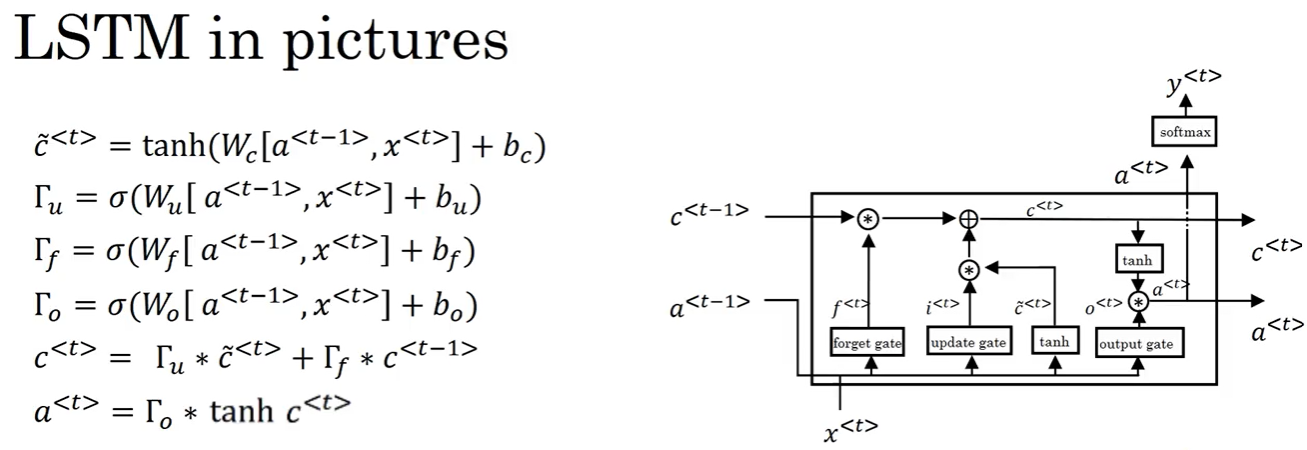

### 🧠 LSTM (Long Short-Term Memory) — Overcoming Vanishing Gradients with More Power Than GRUs

---

### 🔁 Motivation

While GRUs help with vanishing gradients, **LSTMs are even more powerful**. They provide finer control over memory by introducing **separate gates** for **updating**, **forgetting**, and **outputting** information.

---

### 🔍 Key Differences from GRU

| Feature            | GRU                       | LSTM                         |
| ------------------ | ------------------------- | ---------------------------- |
| Gates              | 2 (Update, Reset)         | 3 (Input, Forget, Output)    |
| Memory Cell (`cᵗ`) | Same as activation (`aᵗ`) | Separate from activation     |
| Control Mechanism  | Single update rule        | Independent update & forget  |
| Flexibility        | Simpler, faster           | More expressive, more robust |

---

### 🔢 LSTM Components & Equations

#### Inputs:

* $a^{\langle t-1 \rangle}$: previous hidden state
* $x^{\langle t \rangle}$: current input
* $c^{\langle t-1 \rangle}$: previous cell state

---

#### 1. **Candidate Cell Update**

$$
\tilde{c}^{\langle t \rangle} = \tanh(W_c[a^{\langle t-1 \rangle}, x^{\langle t \rangle}] + b_c)
$$

#### 2. **Input (Update) Gate**

$$
\gamma_u^{\langle t \rangle} = \sigma(W_u[a^{\langle t-1 \rangle}, x^{\langle t \rangle}] + b_u)
$$

#### 3. **Forget Gate**

$$
\gamma_f^{\langle t \rangle} = \sigma(W_f[a^{\langle t-1 \rangle}, x^{\langle t \rangle}] + b_f)
$$

#### 4. **Output Gate**

$$
\gamma_o^{\langle t \rangle} = \sigma(W_o[a^{\langle t-1 \rangle}, x^{\langle t \rangle}] + b_o)
$$

---

### 🧠 Memory and Activation Update

#### 5. **Cell State Update**

$$
c^{\langle t \rangle} = \gamma_u * \tilde{c}^{\langle t \rangle} + \gamma_f * c^{\langle t-1 \rangle}
$$

#### 6. **Hidden State (Output)**

$$
a^{\langle t \rangle} = \gamma_o * \tanh(c^{\langle t \rangle})
$$

---

Total 8 trainable parameters from eq 1-4


### 🔍 Visual Intuition (simplified)

* `xᵗ` and `aᵗ⁻¹` → generate gates + candidate update
* `γᵤ` and `γ_f` control what new info is written and what old memory is kept
* `γ_o` decides how much memory is output

→ By tuning gates appropriately, **LSTM can carry information across many time steps**.

---

### 🔁 Peephole Connections (optional)

* Some variants use **cᵗ⁻¹** as an input to the gates
* This helps gates “peek” into memory for more precision
* Affects **γᵤ**, **γ\_f**, and **γ\_o**

---

### 🧪 Which One to Use: GRU vs LSTM?

| Use Case                             | Recommendation                         |
| ------------------------------------ | -------------------------------------- |
| Simpler model, faster training       | GRU                                    |
| More expressive, long dependencies   | LSTM (preferred default by many today) |
| Large scale model, fewer resources   | GRU                                    |
| Longer-term dependencies, robustness | LSTM                                   |


#### Bi-directional RNN

Here’s a clear and concise summary of the **Bidirectional RNN (BRNN)** concept:

---

### 🔄 What is a Bidirectional RNN?

A **Bidirectional RNN (BRNN)** processes a sequence **in both forward and backward directions**, allowing the model to use **both past and future context** when making predictions at each time step.

---

### 🔍 Motivation

In tasks like **Named Entity Recognition (NER)**, just using past words may not be enough.

* Example: In the sentence
  *"He said Teddy Roosevelt..."*,
  knowing **"Roosevelt"** comes after **"Teddy"** helps you recognize “Teddy” as part of a person’s name.
  → Unidirectional RNNs (left to right) **can’t use future context**.

---

### 🧱 How a BRNN Works

Given input sequence:

$$
x^{\langle 1 \rangle}, x^{\langle 2 \rangle}, \dots, x^{\langle T \rangle}
$$

BRNN uses:

1. **Forward RNN**:

   * Processes input **left to right**
   * Computes $\overrightarrow{a}^{\langle t \rangle}$

2. **Backward RNN**:

   * Processes input **right to left**
   * Computes $\overleftarrow{a}^{\langle t \rangle}$

3. **Concatenation of activations**:

   * At each time step $t$, the hidden state is:

     $$
     a^{\langle t \rangle} = [\overrightarrow{a}^{\langle t \rangle}; \overleftarrow{a}^{\langle t \rangle}]
     $$

4. **Prediction at time t**:

   $$
   \hat{y}^{\langle t \rangle} = g(W_y \cdot a^{\langle t \rangle} + b_y)
   $$

---

### ✅ Advantages

* Can use **full context** (past + future) for better predictions.
* Works well for **NLP tasks** like:

  * POS tagging
  * NER
  * Sentiment classification (if full text is available)

---

### ❗ Limitation

* Requires the **entire input sequence** upfront.
* Not suitable for **real-time or streaming** tasks (like real-time speech recognition), unless modified.

---

### 🧠 Used With

* BRNN can be built using any RNN unit:

  * Standard RNN
  * GRU
  * LSTM

---

### 📌 Summary Table

| Feature                 | BRNN                                |
| ----------------------- | ----------------------------------- |
| Direction               | Forward + Backward                  |
| Hidden state per step   | Concatenation of forward + backward |
| Context used for output | Past + Future                       |
| Suitable for streaming? | ❌ No                                |
| Commonly used with      | LSTM / GRU (esp. in NLP)            |


### Deep network

Here’s a **summary of Deep RNNs** from the video:

---

### 🧱 What is a Deep RNN?

A **Deep RNN** is built by **stacking multiple RNN layers vertically**—one on top of another—so that the output from one RNN layer becomes the input to the next.

This is similar in concept to deep feedforward networks, but **extended over time**.

---

### 📐 Structure & Notation

* For a **1-layer RNN**:

  $$
  a^{\langle t \rangle} = g(W_a \cdot [a^{\langle t-1 \rangle}, x^{\langle t \rangle}] + b_a)
  $$

* For a **deep RNN with L layers**:

  $$
  a^{[l]\langle t \rangle} = g(W_a^{[l]} \cdot [a^{[l]\langle t-1 \rangle}, a^{[l-1]\langle t \rangle}] + b_a^{[l]})
  $$

  where:

  * $a^{[l]\langle t \rangle}$ is the activation at **layer $l$** and **time step $t$**
  * $W_a^{[l]}$, $b_a^{[l]}$ are **shared across all timesteps** in that layer
  * Input layer: $a^{[0]\langle t \rangle} = x^{\langle t \rangle}$

---

### 🔄 Forward Pass Flow

At each timestep $t$, for each layer $l$:

* Information flows **from left to right in time**
* And **from bottom to top through layers**

So a unit in the middle (say $a^{[2]\langle 3 \rangle}$) depends on:

* Its previous timestep $a^{[2]\langle 2 \rangle}$
* And the output from the layer below $a^{[1]\langle 3 \rangle}$

---

### 🧠 Example Architectures

* **Stacked RNN** (e.g., 3 layers deep, recurrent across time)
* **Stacked BRNN** (bidirectional at each layer)
* **RNN + Feedforward Layers**:

  * Add dense layers after the RNN layers, **not connected across time**

---

### ⚙️ RNN Block Types

Each layer can be:

* A **standard RNN unit**
* A **GRU**
* Or an **LSTM**

This allows flexible design depending on your use case.

---

### ⚠️ Notes

* Deep RNNs are **computationally expensive** and can be hard to train.
* Unlike feedforward nets with 100+ layers, RNNs often stop at 2–3 layers because of:

  * **Long temporal dependencies**
  * Increased training complexity

---

### ✅ Key Takeaways

| Concept                 | Deep RNNs                     |
| ----------------------- | ----------------------------- |
| Vertical stacking       | Yes (layers of RNNs)          |
| Time unrolling          | Still unrolled through time   |
| Parameter sharing       | Across time within each layer |
| Layers used             | RNN / GRU / LSTM / BRNN       |
| Usual depth             | 2–3 layers due to complexity  |
| Additional dense layers | Can be added after RNN blocks |


#### Word Embeddings 

Here’s a concise summary of the video on **Word Embeddings** and their role in **Natural Language Processing (NLP)**:

---

### 🧠 **Why Word Embeddings?**

* Traditional method: Represent each word as a **one-hot vector** (e.g., 10,000-dimensional, with a single 1 and rest 0s).
* **Limitations of one-hot**:

  * All words are equally far apart.
  * No concept of similarity (e.g., *apple* and *orange* are as dissimilar as *apple* and *king*).
  * Can't generalize knowledge across similar words.

---

### 🌐 **What Are Word Embeddings?**

* A **learned vector representation** of words in a continuous vector space (e.g., 300-dimensional).
* Similar words (semantically or syntactically) have similar embeddings.
* Example feature interpretations:

  * Gender: male ↔ female
  * Royalty: king/queen ↔ commoner
  * Food: apple/orange ↔ non-food
  * Age, animacy, cost, size, etc.

---

### 📏 **Mathematical Representation**

* Replace one-hot $o_{5391}$ with learned embedding vector $e_{5391} \in \mathbb{R}^{300}$

* Each word $w_i$ has:

  $$
  \text{embedding}(w_i) = e_i = [e_i^{(1)}, e_i^{(2)}, ..., e_i^{(300)}]
  $$

* These embeddings are **learned from data**, often via language models.

---

### 🔁 **Advantages**

* Allows models to **generalize better**:

  * If the model learns “orange juice” is valid, it can infer “apple juice” is likely too.
* Captures **semantic relationships** like:

  $$
  \text{man} : \text{woman} :: \text{king} : \text{queen}
  $$
* Enables **clustering of similar concepts** (e.g., fruits, animals, numbers).

---

### 🎨 **Visualization**

* Embeddings exist in **300D space** (or other sizes).
* For visualization:

  * Algorithms like **t-SNE** reduce dimensionality to 2D
  * You see clusters of related words (e.g., man/woman, king/queen, apple/orange)

---

### **Embedding**

* **Embedding** = mapping a discrete object (word) into a point in continuous vector space
* Example: Word “orange” → vector in $\mathbb{R}^{300}$




### 🔁 **From Embeddings to NLP Applications**

You’ve learned what word embeddings are. Now, here’s how to use them in actual NLP tasks like **Named Entity Recognition (NER)**.

---

### 📌 **NER Example:**

* **Training example**:
  *“Sally Johnson is an orange farmer”* → Model predicts “Sally Johnson” is a person.

* **Generalization with embeddings**:
  If the model sees *“Robert Lin is an apple farmer”*, the word embeddings help it realize:

  * **Apple ≈ Orange**
  * **Farmer ≈ Cultivator**

  Even for a rare phrase like *“durian cultivator”*, embeddings help generalize the concept of “person.”

---

### 🔄 **Transfer Learning with Word Embeddings**

1. **Learn embeddings** from large unlabeled corpora (e.g., billions of words from the internet).
2. **Transfer** these embeddings to downstream NLP tasks (e.g., NER, summarization) with smaller labeled datasets.
3. **Optional fine-tuning**: Adjust embeddings further if you have a decently large labeled dataset.

---

### 🎯 **Why It Works:**

* Embeddings capture **semantic similarity** (e.g., *apple*, *orange*, *durian* are close).
* Enables **generalization** even for unseen or rare words in the target task.

---

### ⚖️ **When to Fine-Tune?**

* ✅ Fine-tune if task dataset is large.
* ❌ Skip fine-tuning if task dataset is small — use fixed pretrained embeddings instead.

---

### 📚 **Tasks Where Embeddings Help:**

* NER (Named Entity Recognition)
* Text Summarization
* Co-reference Resolution
* Parsing

📉 **Less helpful** in:

* Language Modeling
* Machine Translation (if large data available)

---

### 🔍 **Word Embedding vs Face Encoding**

| Concept       | Word Embeddings                   | Face Encodings                     |
| ------------- | --------------------------------- | ---------------------------------- |
| Input         | Fixed vocabulary words            | Any face image                     |
| Output Vector | Fixed learned vector (e.g., 300D) | Neural network output (e.g., 128D) |
| Goal          | Capture word similarity           | Capture identity similarity        |
| Learning Data | Text corpora                      | Labeled face images                |
| Flexibility   | Limited to known vocab            | Generalizable to new inputs        |

Note: Terms *embedding* and *encoding* are often used interchangeably.

---

### ✅ **Key Takeaways**

* Word embeddings enable **transfer learning** in NLP.
* Replace sparse one-hot vectors with **dense feature vectors**.
* Make it easier for models to learn and **generalize with less data**.
* Serve as a foundation for modern NLP tasks.

---

Here’s a structured summary of the video on **Analogy Reasoning with Word Embeddings**:

---

### 🧠 **Purpose**

Word embeddings don’t just help with basic NLP tasks — they also support **analogy reasoning**, such as:

> **“Man is to Woman as King is to \_\_\_?”** → **Queen**

This isn’t just a neat trick — it reflects how word embeddings capture **semantic relationships** as **vector operations**.

---

### 🔢 **How It Works (Vector Arithmetic)**

* Let:

  * $e_{\text{man}}, e_{\text{woman}}, e_{\text{king}}, e_{\text{queen}}$ be their word vectors.
* Compute:

  $$
  e_{\text{man}} - e_{\text{woman}} \approx e_{\text{king}} - e_{\text{queen}}
  $$
* Rearranged:

  $$
  e_{\text{queen}} \approx e_{\text{king}} - e_{\text{man}} + e_{\text{woman}}
  $$
* To solve analogy:

  $$
  \text{Find word } w \text{ that maximizes similarity to } e_{\text{king}} - e_{\text{man}} + e_{\text{woman}}
  $$

---

### 📐 **Similarity Measure**

* **Cosine Similarity** (most common):

  $$
  \text{cos\_sim}(u, v) = \frac{u^\top v}{\|u\| \|v\|}
  $$

  * +1 if vectors point in same direction
  * 0 if perpendicular
  * –1 if opposite direction

* **Alternative**: Negative squared Euclidean distance:

  $$
  -\|u - v\|^2
  $$

  (Used less often)

---

### 📊 **Why This Works**

* Embeddings are in high-dimensional space (e.g., 300D)
* Certain **semantic relationships** are consistently encoded as **vector directions**

  * Gender: $e_{\text{man}} - e_{\text{woman}}$
  * Capital-city: $e_{\text{Ottawa}} - e_{\text{Canada}} \approx e_{\text{Nairobi}} - e_{\text{Kenya}}$
  * Degree: $e_{\text{big}} - e_{\text{bigger}} \approx e_{\text{tall}} - e_{\text{taller}}$
  * Currency: $e_{\text{yen}} - e_{\text{Japan}} \approx e_{\text{ruble}} - e_{\text{Russia}}$

---

### 🌐 **Important Notes**

* **Dimensionality**: These analogies work in **300D**, not after non-linear projection (e.g., t-SNE plots). t-SNE is for visualization, not arithmetic.
* This analogy behavior helped researchers **understand the semantic power** of embeddings when it was first discovered by **Tomas Mikolov et al.**

---

### ✅ **Key Takeaways**

* Word embeddings encode **semantic relationships** as **geometric transformations**
* You can reason with them using simple vector arithmetic
* **Cosine similarity** is the standard way to evaluate similarity
* These relationships emerge naturally by training on large unlabeled text corpora


---

### 📐 **Embedding Matrix Setup**

* Let:

  * Vocabulary size = 10,000 (or 10,001 with `<UNK>` token)
  * Embedding dimension = 300
* The **embedding matrix $E$** is:

  $$
  E \in \mathbb{R}^{300 \times 10{,}000}
  $$

  * Each **column** $E_i$ is a **300-dimensional vector** (embedding) for word $i$

---

### 🔢 **How It Works**

* Represent a word (e.g., "Orange") as a **one-hot vector** $o_{6257} \in \mathbb{R}^{10{,}000}$
  (i.e., a vector of all 0’s except a 1 at index 6257)
* To get the embedding of "Orange":

  $$
  E \cdot o_{6257} = e_{6257}
  $$

  * The result is a **300×1 vector** — the embedding of "Orange"
  * This works because multiplying $E$ by a one-hot vector selects the corresponding column

---

### 🔁 **In Practice**

* During training, the model **learns the values in matrix $E$** such that similar words (based on context) end up with similar embeddings.
* The operation $E \cdot o_i$ is a **lookup** for embedding vector $e_i$

---

### ✅ **Key Takeaways**

* Word embeddings are stored as **columns in a trainable matrix $E$**
* One-hot encoding allows clean vector selection via matrix multiplication
* Each word is represented as a **dense 300D vector** (instead of sparse 10,000D one-hot)


###  **How to Learn Word Embeddings via Language Modeling**

---

### 📌 **Key Idea**

* Word embeddings can be learned by **training a neural network language model** that predicts the next word in a sentence from its **context words**.
* These embeddings are stored in an **embedding matrix $E$**, where each column is a vector representing a word.

---

### 🔧 **Basic Setup: Neural Language Model**

1. **Input**: Context words (e.g., last 4 words before the target word)
2. **Embedding lookup**: Each word → one-hot → multiplied by matrix $E$ → embedding vector
3. **Concatenation**: Embeddings of context words form a fixed-size vector (e.g., 4 words × 300D = 1200D)
4. **Neural Network Layers**:

   * Hidden layer (with weights $W_1, b_1$)
   * Softmax output layer (with weights $W_2, b_2$) over vocabulary (e.g., 10,000 words)
5. **Target**: The next word (e.g., "juice")

---

### 🧠 **Why It Works**

* If "orange juice" and "apple juice" both appear often, the model will learn to **embed "orange" and "apple" similarly** to make accurate predictions.
* Hence, the **goal of predicting the next word helps naturally shape word embeddings**.

---

### 🔄 **Generalizations of Context**

Researchers experimented with other ways to define **context** to learn embeddings:

* Previous 4 words → predict target word (standard language model)
* 4 words before + 4 words after target → predict middle word (used for Word2Vec CBOW)
* Just 1 previous word → predict next word
* Just 1 nearby word (e.g., "glass") → predict a word close to it (basis of **Skip-Gram model**)

Here is a concise summary of the **Word2Vec Skip-Gram model** video:

---

### 🧠 **Goal**

Learn **word embeddings** efficiently using a simple, scalable method — the **Skip-Gram model** from the **Word2Vec** framework.

---

### 📌 **Main Idea (Skip-Gram Model)**

Given a **center word** (context), predict surrounding words (targets) within a window.

#### 🔄 Example

For the sentence:

> *I want a glass of orange juice with my cereal*

If the **context** word is `"orange"` and the window is ±5, possible **target words**: `"glass"`, `"juice"`, `"with"`, `"my"` etc.

---

### 🏗️ **Model Architecture**

1. **Input**: One-hot vector for context word $o_c \in \mathbb{R}^{10,000}$

2. **Embedding Lookup**:

   $$
   e_c = E \cdot o_c \quad \text{(embedding matrix: } E \in \mathbb{R}^{300 \times 10,000})
   $$

3. **Softmax Output**:
   Probability of target word $t$:

   $$
   P(t | c) = \frac{e^{\theta_t^\top e_c}}{\sum_{j=1}^{|V|} e^{\theta_j^\top e_c}}
   $$

   Where:

   * $\theta_t$ is the weight vector for target word $t$
   * Output is a softmax over all words in the vocabulary

4. **Loss Function**:
   Negative log likelihood:

   $$
   \mathcal{L} = - \log P(t | c)
   $$


SO basically embedding matrix helps to convert one hot to vector with features and theta basically helps to predict the next word using the vector outputted from embedding matrix and make a prediction. 

In nutshell improving E helps us to get a better presentation of a word  improving theta helps us to improve prediction on the trasformed word. 

---

### ⚠️ **Problem: Expensive Softmax**

* Computing the softmax denominator involves summing over **all vocabulary words** (e.g., 10,000+), which is **computationally slow**.

---

### ⚡ **Solution: Speedups**

1. **Hierarchical Softmax**

   * Builds a **tree structure** over the vocabulary
   * Each word is a **leaf node**
   * Traversal from root to leaf replaces full softmax
   * **Logarithmic complexity** $O(\log |V|)$

Hierarchical Softmax (H-Softmax) is a technique to **speed up softmax** computation for large vocabularies by **replacing a flat softmax layer with a binary tree**. It transforms the multi-class classification problem (over say, 100,000 words) into a **series of binary decisions** along a path in the tree.

Let’s go step by step through the full process.

---

## 🧠 Goal:

Predict a target word $w \in \mathcal{V}$ (where $\mathcal{V}$ is vocabulary) using the word embedding of a context word.

---

## 🪜 Step-by-Step: Hierarchical Softmax

### 🔹 Step 1: **Build a Binary Tree**

* Create a binary tree with each **leaf node representing a word** in the vocabulary.
* Internal nodes represent **binary decisions** (left/right).
* You can use a **Huffman tree** so frequent words have **shorter paths** (i.e., fewer computations).

**Example:** Let’s say our vocabulary is:

```
Vocab = ["cat", "dog", "apple", "car", "bike", "tree", "person"]
```

Suppose you build a tree like this (simplified):

```
              [Root]
             /     \
         [N1]       [N2]
        /   \       /   \
     "cat" "dog" [N3]   "person"
                 / \
              "apple" [N4]
                      / \
                  "car" "bike"
```

Each word now has a **unique path** from root to leaf:

* `"cat"`: Root → N1 → Left
* `"bike"`: Root → N2 → N3 → N4 → Right
* and so on…

---

### 🔹 Step 2: **For Each Word, Store Its Path**

For each word $w$, store:

* The sequence of internal nodes $n_1, n_2, ..., n_{L-1}$ (excluding leaf)
* The sequence of binary decisions $b_1, b_2, ..., b_{L-1}$ (left = 0, right = 1)

**Example for "bike":**

* Path: \[Root, N2, N3, N4]
* Decisions: \[Right, Right, Right] → all 1s

---

### 🔹 Step 3: **Train Logistic Classifier at Each Internal Node**

Each **internal node** (e.g., Root, N2, etc.) has its **own weight vector** $\theta_n$.
We train a **binary logistic regression** at each internal node:

At each step $i$, compute:

$$
P(b_i | h) = \sigma\left( (-1)^{b_i} \cdot \theta_{n_i}^T h \right)
$$

* $h$: context word embedding (output of embedding matrix)
* $\theta_{n_i}$: weights of internal node $n_i$
* $b_i$: 0 (left) or 1 (right)
* $\sigma$: sigmoid function

**Example:** Let’s say context word is "apple", and we're trying to predict `"bike"`

* Compute $P(\text{"bike"} | h)$ as:

$$
P(\text{"bike"}|h) = \prod_{i=1}^{L-1} \sigma\left( (-1)^{b_i} \cdot \theta_{n_i}^T h \right)
$$

This is the probability of taking all correct decisions to reach "bike".

---

### 🔹 Step 4: **Loss Function**

Negative log-likelihood for the correct word path:

$$
\mathcal{L} = -\sum_{i=1}^{L-1} \log \sigma\left( (-1)^{b_i} \cdot \theta_{n_i}^T h \right)
$$

Backpropagate this loss to update:

* The embedding matrix $E$
* The path node weights $\theta_{n_i}$

---

## 💡 Why It’s Efficient

* In **flat softmax**, computing $\hat{y} = \text{softmax}(W h)$ is $\mathcal{O}(|\mathcal{V}|)$
* In **hierarchical softmax**, it’s $\mathcal{O}(\log |\mathcal{V}|)$ (because you only traverse a single path in the tree)

This makes it **much faster** for large vocabularies (e.g., 1M words).

---

## ✅ Summary Table

| Component               | Purpose                                     |
| ----------------------- | ------------------------------------------- |
| Binary Tree             | Organizes words to allow log-time lookup    |
| Internal Nodes          | Logistic classifiers for binary decisions   |
| Path to word            | Defines sequence of classifiers to evaluate |
| Embedding Matrix $E$    | Converts one-hot to dense vector            |
| Node weights $\theta_n$ | Predict left/right decision given embedding |



2. **Context Sampling Strategy**

   * Avoid oversampling common words like `"the"`, `"of"`, etc.
   * Apply heuristics to **downsample frequent words** and **upsample rare words** (like `"durian"`)

---

### 🔁 **CBOW (Continuous Bag of Words)**

* Also introduced in the original Word2Vec paper
* Uses **surrounding words as input** to predict **middle word**
* Skip-Gram and CBOW are both useful — CBOW is faster but may underperform on infrequent words

---

### ✅ **Summary**

* **Skip-Gram** learns word embeddings by predicting nearby words from a single word
* Learns efficiently using **simple architecture**: embedding lookup → softmax
* **Key bottleneck** is computing softmax over large vocabularies
* Next: **Negative Sampling** — a technique to further speed up training

---

Would you like a visual diagram of the Skip-Gram architecture or move on to **Negative Sampling** explanation?


## **Problem with Skip-Gram + Softmax**

* Skip-Gram model: learns word embeddings by predicting nearby words.
* **Issue**: Softmax is **computationally expensive** — it sums over all vocabulary words (e.g., 10,000+).

---

## ✅ **Negative Sampling: A More Efficient Alternative**

### 🔹 **Key Idea**

Instead of predicting **which word from entire vocab** is likely (softmax),
**reformulate** the task as **multiple binary classification problems**:

> “Given a pair of words (context, target), is this a real pair or a fake (random) one?”

---

## 🛠️ **How It Works**

Let’s walk through an **end-to-end example of negative sampling** in the skip-gram Word2Vec model — both conceptually and mathematically.

---

### 🔧 Problem Setup

* Suppose your sentence is:
  **“I drank orange juice this morning.”**
* Vocabulary size = 10,000 words
* Embedding dimension = 4 (for simplicity)
* Window size = ±2
* Context word = `"orange"`
* Target (positive) word = `"juice"`
* Negative samples (`k=2`) = `"table"`, `"king"`

---

### 📌 Step-by-step Process

#### **Step 1: Convert words to one-hot vectors**

Assume the word `"orange"` has index `6257`, `"juice"` is `4834`, `"table"` is `9123`, `"king"` is `777`.

So the one-hot for `"orange"` =

$$
o_{orange} = [0, 0, ..., 1, ..., 0] \in \mathbb{R}^{10000} \quad \text{(1 at index 6257)}
$$

---

#### **Step 2: Get embedding of context word using input embedding matrix $E$**

Let $E \in \mathbb{R}^{4 \times 10000}$ be the input embedding matrix. Then:

$$
\mathbf{e}_{orange} = E \cdot o_{orange} = \text{column 6257 of } E = \mathbf{e}_c \in \mathbb{R}^4
$$

Let’s say:

$$
\mathbf{e}_c = \mathbf{e}_{orange} = \begin{bmatrix} 0.5 \\ -0.1 \\ 0.3 \\ 0.7 \end{bmatrix}
$$

---

#### **Step 3: Get embeddings of target/negative words from output embedding matrix $\Theta$**

Let $\Theta \in \mathbb{R}^{4 \times 10000}$ be the output embedding matrix.

Suppose:

* $\theta_{juice} = \begin{bmatrix} 0.6 \\ -0.2 \\ 0.1 \\ 0.4 \end{bmatrix}$
* $\theta_{table} = \begin{bmatrix} -0.1 \\ 0.4 \\ 0.5 \\ -0.6 \end{bmatrix}$
* $\theta_{king} = \begin{bmatrix} 0.3 \\ 0.3 \\ -0.2 \\ 0.2 \end{bmatrix}$

---

#### **Step 4: Compute dot products**

$$
s_{pos} = \theta_{juice}^T \cdot \mathbf{e}_{orange} = (0.6)(0.5) + (-0.2)(-0.1) + (0.1)(0.3) + (0.4)(0.7) = 0.3 + 0.02 + 0.03 + 0.28 = \mathbf{0.63}
$$

$$
s_{neg1} = \theta_{table}^T \cdot \mathbf{e}_{orange} = -0.05 - 0.04 + 0.15 - 0.42 = \mathbf{-0.36}
$$

$$
s_{neg2} = \theta_{king}^T \cdot \mathbf{e}_{orange} = 0.15 - 0.03 - 0.06 + 0.14 = \mathbf{0.20}
$$

---

#### **Step 5: Compute sigmoid probabilities**

$$
\sigma(s) = \frac{1}{1 + e^{-s}}
$$

* $\sigma_{pos} = \sigma(0.63) \approx 0.652$
* $\sigma_{neg1} = \sigma(-0.36) \approx 0.410$
* $\sigma_{neg2} = \sigma(0.20) \approx 0.550$

---

#### **Step 6: Compute loss**

Using **binary cross-entropy loss** for each pair:

$$
\mathcal{L} = -\log \sigma(s_{pos}) - \sum_{i=1}^{k} \log(1 - \sigma(s_{neg,i}))
$$

$$
\mathcal{L} = -\log(0.652) - \log(1 - 0.410) - \log(1 - 0.550)
$$

$$
\mathcal{L} \approx -(-0.428) - (-0.528) - (-0.798) = \boxed{1.754}
$$

---

#### **Step 7: Gradient Descent Update**

We now compute gradients of the loss w\.r.t.:

* $\mathbf{e}_{orange}$
* $\theta_{juice}, \theta_{table}, \theta_{king}$

Then we update them using:

$$
\theta \leftarrow \theta - \eta \cdot \frac{\partial \mathcal{L}}{\partial \theta}
$$

$$
\mathbf{e}_{orange} \leftarrow \mathbf{e}_{orange} - \eta \cdot \frac{\partial \mathcal{L}}{\partial \mathbf{e}_{orange}}
$$

(You don’t need to update all 10,000 output embeddings — only for the 1 positive + k negatives)

---

### ✅ Summary

| Step | Operation                                                                     |
| ---- | ----------------------------------------------------------------------------- |
| 1    | One-hot encoding of context word                                              |
| 2    | Look up embedding using input matrix $E$                                      |
| 3    | Look up embeddings of positive and negative words from output matrix $\Theta$ |
| 4    | Compute dot products                                                          |
| 5    | Apply sigmoid to get probabilities                                            |
| 6    | Compute loss using binary cross-entropy                                       |
| 7    | Backpropagate and update parameters                                           |

---

Would you like the **actual gradients computed** for this example as well?

---

## 🧠 **Learning Objective**

For each (context, target) pair:

* Use **logistic regression** to predict whether it's a real (1) or fake (0) pair.

$$
P(y = 1 | c, t) = \sigma(\theta_t^\top \cdot e_c)
$$

* $\theta_t$: output vector of target word
* $e_c$: embedding of context word
* $\sigma$: sigmoid function


## ⚙️ **Sampling Strategy for Negative Words**

* **Don’t** sample uniformly
* **Don’t** sample by raw frequency (you’d get “the”, “of”, etc. too much)
* ✅ **Sample using heuristic**:

  $$
  P(w) \propto f(w)^{3/4}
  $$

  where $f(w)$ is word frequency in corpus


### 🔍 **What is GloVe?**

GloVe (Global Vectors for Word Representation) is a word embedding algorithm developed by **Pennington, Socher, and Manning**.
Unlike Word2Vec, which relies on **predicting** nearby words, GloVe is based on **global co-occurrence statistics** from the corpus.

---

### 🧠 **Core Idea**

* Build a **co-occurrence matrix** $X_{ij}$, where each cell counts how often word $i$ appears in the context of word $j$ (e.g., within ±10 words).
* Then **learn vector representations** such that the **dot product** of their embeddings predicts the **log of the count**.

$$
\text{Goal:} \quad \theta_i^\top e_j \approx \log(X_{ij})
$$

Where:

* $\theta_i$: output embedding of word $i$
* $e_j$: input embedding of word $j$
* $X_{ij}$: co-occurrence count

---

### ⚙️ **Optimization Objective**

$$
\min_{\theta, e} \sum_{i,j} f(X_{ij}) \cdot \left(\theta_i^\top e_j - \log X_{ij}\right)^2
$$

* $f(X_{ij})$: weighting function

  * Zero if $X_{ij} = 0$
  * Gives more importance to mid-frequency pairs (avoids overweighting very frequent/common words)
* Only co-occurring word pairs are considered to avoid computing log(0).

---

### 💡 **Why it works**

* Embeddings are learned to reflect how **strongly words co-occur**, not just if they do.
* Captures both **global** and **local** semantics.
* Learns similarity in a way that aligns with **ratios** of co-occurrence, which can reflect deeper semantics (e.g., king\:queen ≈ man\:woman).

---

### 🧪 **Symmetry & Averaging**

* $\theta_i$ and $e_j$ play **symmetric roles**.
* At the end of training, the **final embedding** for a word is often:

$$
\text{embedding}(w) = \frac{\theta_w + e_w}{2}
$$

---

### 📉 **Interpretability of Dimensions**

* Unlike manual features (e.g., "gender" or "foodness"), GloVe doesn’t assign **explicit meaning** to individual dimensions.
* Due to linear transformations, even if an axis represents something like “royalty,” it may be **rotated/mixed** with other concepts.
* But relational properties (e.g., word analogies like *king - man + woman ≈ queen*) still hold due to **vector space geometry**.

---

### ✅ **Pros of GloVe**

* Efficient with large corpora
* Simple objective
* Captures both **global structure** (co-occurrence matrix) and **local context** (through windowing)

---

### 🧾 Example (Conceptual):

If:

* "ice" often co-occurs with "cold" and rarely with "steam"
* "fire" often co-occurs with "hot" and rarely with "ice"

Then GloVe will try to learn:

* $\text{embedding(ice)} \cdot \text{embedding(cold)} \gg \text{embedding(ice)} \cdot \text{embedding(steam)}$
* And similar for "fire" and "hot"

---

### 🔚 Summary

| Aspect          | GloVe                                     |
| --------------- | ----------------------------------------- |
| Uses            | Co-occurrence counts (global)             |
| Optimization    | Dot product of embeddings ≈ log of count  |
| Parameters      | Input & output embeddings                 |
| Final vector    | Average of input and output embeddings    |
| Special feature | Symmetric treatment of context & target   |
| Weakness        | Dimensions are not directly interpretable |

---

Would you like a **numerical example** with fake co-occurrence counts to see how the actual optimization works?


Word2vec vs Glove comparison 

Let's break down how word embeddings are learned for the sentence:

**“I'm here but I was there yesterday so can you please send me the details here?”**

using two popular algorithms:

---

### 🔹 1. **Word2Vec (Skip-Gram)**

**Goal:** Given a center word, predict context words within a window.

**Sentence Preprocessing:**
Let’s tokenize the sentence:

```plaintext
[I'm, here, but, I, was, there, yesterday, so, can, you, please, send, me, the, details, here]
```

Let’s say we use a window size of **2** (i.e., for each word, we predict 2 words before and after).

---

#### ➤ Step 1: Generate Training Pairs

For each center word, create pairs of (center, context).
Example for center = "was":

```plaintext
(was, I), (was, there), (I, was), (there, was)
```

Full pairs for the whole sentence (for simplicity, using a partial list):

```plaintext
(I’m, here), (I’m, but)  
(here, I’m), (here, but), (here, I)  
(but, I’m), (but, here), (but, I), (but, was)  
...  
(details, the), (details, here)
```

---

#### ➤ Step 2: One-Hot Encoding

Assume a vocabulary of size $V = 20$.
Each word is represented as a one-hot vector $\mathbf{o} \in \mathbb{R}^{V}$.

For example:

```plaintext
"I'm"   → [1, 0, 0, ..., 0]  
"here" → [0, 1, 0, ..., 0]  
```

---

#### ➤ Step 3: Embedding Lookup

Let:

* $E \in \mathbb{R}^{d \times V}$: embedding matrix (e.g., $d = 50$)
* $\mathbf{o}_c \in \mathbb{R}^{V}$: one-hot for center word
* $\mathbf{e}_c = E \cdot \mathbf{o}_c \in \mathbb{R}^{d}$: embedding vector for center word

This is just column extraction from matrix $E$.

---

#### ➤ Step 4: Score Computation

Let:

* $\Theta \in \mathbb{R}^{V \times d}$: output weight matrix
* $\theta_t \in \mathbb{R}^{d}$: row vector for context word $t$

Then the score for target word is:

$$
s = \theta_t^T \cdot \mathbf{e}_c
$$

Apply softmax over all possible target words to get probabilities:

$$
P(t \mid c) = \frac{\exp(\theta_t^T \cdot \mathbf{e}_c)}{\sum_{j=1}^{V} \exp(\theta_j^T \cdot \mathbf{e}_c)}
$$

---

#### ➤ Step 5: Loss (Negative Log Likelihood)

For true context word $t$, we minimize:

$$
\mathcal{L} = -\log P(t \mid c)
$$

Backpropagate this to update both $E$ and $\Theta$.

---

### 🔹 2. **GloVe (Global Vectors)**

**Goal:** Learn embeddings such that dot product reflects word co-occurrence.

---

#### ➤ Step 1: Build Co-Occurrence Matrix $X$

Create a matrix $X \in \mathbb{R}^{V \times V}$, where:

* $X_{ij}$ = number of times word $i$ appears in the context window of word $j$

Example:

```plaintext
X["I", "was"] = 1  
X["was", "there"] = 1  
X["here", "details"] = 1  
```

Count all co-occurrences (symmetric if window is symmetric).

---

#### ➤ Step 2: GloVe Objective Function

For each word pair $(i, j)$ with $X_{ij} > 0$:

$$
\mathcal{L}_{ij} = f(X_{ij}) \left( \theta_i^T e_j + b_i + b_j - \log X_{ij} \right)^2
$$

* $\theta_i$: target word embedding
* $e_j$: context word embedding
* $b_i, b_j$: biases
* $f(X_{ij})$: weighting function (e.g., $f(x) = (x / x_{\max})^{0.75}$)

---

#### ➤ Step 3: Optimization

Minimize:

$$
\mathcal{L} = \sum_{i=1}^V \sum_{j=1}^V \mathcal{L}_{ij}
$$

using gradient descent.

---

#### ➤ Step 4: Final Embedding

After training:

$$
\text{Final embedding for word } i = \frac{1}{2} (e_i + \theta_i)
$$

---

### 🔸 Summary Table

| Component           | Word2Vec (Skip-gram)                  | GloVe                                 |
| ------------------- | ------------------------------------- | ------------------------------------- |
| Training signal     | Context-target word pairs             | Co-occurrence counts                  |
| Input               | One-hot word vector                   | Co-occurrence matrix                  |
| Embedding lookup    | $\mathbf{e}_c = E \cdot \mathbf{o}_c$ | $e_i, \theta_j \in \mathbb{R}^d$      |
| Output matrix       | $\Theta \in \mathbb{R}^{V \times d}$  | $\theta_j \in \mathbb{R}^d$           |
| Cost                | Cross-entropy / softmax               | $(\theta^T e + b_i + b_j - \log x)^2$ |
| Optimization target | Maximize $P(t \mid c)$                | Fit dot product to $\log X_{ij}$      |
| Final embedding     | Row in matrix $E$                     | $(e_i + \theta_i)/2$                  |


In GloVe, both the target embedding and the context embedding 


randomly initialized at the beginning (typically small random values),

and then learned entirely from scratch using gradient descent on the co-occurrence-based loss function.

###  **What is Sentiment Classification?**

* It’s the task of determining whether a text expresses a **positive**, **neutral**, or **negative** sentiment (e.g., 1 to 5 star reviews).
* Useful for analyzing customer feedback on platforms like **Twitter**, **Instagram**, **restaurant reviews**, etc.

---

### 🏗️ **How to Perform Sentiment Classification Using Word Embeddings**

#### 1. **Challenge**:

* Labeled training data is often **limited** (e.g., 10K–100K examples).
* **Word embeddings** help overcome this by capturing word meanings learned from **large unlabeled corpora** (e.g., billions of words).

---

### 🛠️ **Two Model Architectures**

#### **A. Bag of Words + Average Embeddings**

* For a sentence like:
  `"The dessert is excellent"`
* **Steps**:

  1. Convert each word to a one-hot vector.
  2. Multiply with pretrained **embedding matrix E** (e.g., 300-dim).
  3. **Average** or **sum** the embeddings.
  4. Feed the resulting vector to a **softmax classifier** to predict star rating (1–5).
* ✅ **Pros**: Simple, works for variable-length sentences.
* ❌ **Cons**: **Ignores word order**, can misinterpret sentences like:
  `"Completely lacking in good taste..."` → might wrongly seem positive due to repeated word “good”.

---

#### **B. RNN-based Model**

* Uses a **Recurrent Neural Network** to capture word sequence.
* **Steps**:

  1. Convert words to one-hot vectors → embedding vectors.
  2. Feed sequence into an **RNN** (e.g., many-to-one setup).
  3. Use the final hidden state to predict sentiment.
* ✅ **Pros**: Preserves **word order** and context (e.g., understands “not good” is negative).
* ❌ **Cons**: More computationally intensive.

---

### 💡 **Why Use Word Embeddings?**

* You can **pretrain** embeddings on large unlabeled text (e.g., Wikipedia).
* Even **rare or unseen words** in your labeled training set may still be **recognized** due to good pretrained embeddings.
* Allows **generalization** beyond the small labeled dataset.

---

### 🔁 Summary of Key Advantages

| Feature                          | Bag of Words + Average | RNN-Based  |
| -------------------------------- | ---------------------- | ---------- |
| Simple to implement              | ✅                      | ❌          |
| Works with variable length input | ✅                      | ✅          |
| Captures word order              | ❌                      | ✅          |
| Generalizes with small datasets  | ✅ (with pretrained E)  | ✅ (with E) |


Here’s a **concise summary** of the video on **removing bias from word embeddings**:

---

## 🎯 **Goal**

* Reduce **undesirable bias** (e.g., **gender**, **ethnicity**, **socioeconomic status**) in **word embeddings**, especially because ML models are now used in **critical decisions** (e.g., hiring, loans, sentencing).
* Focus of this video: **Gender bias** in word embeddings.

---

## ⚠️ **Problem**

Word embeddings often **reflect real-world biases** from training data.
Examples of biased analogies:

* `Man : Computer_Programmer :: Woman : Homemaker` ❌
* `Father : Doctor :: Mother : Nurse` ❌

These analogies reinforce **harmful stereotypes**.

---

## 🧪 **Approach (From Bolukbasi et al., 2016)**

### 1. **Identify the Bias Direction**

* Use word pairs like (`he`–`she`, `man`–`woman`) to compute difference vectors.
* **Average** these to get the **bias direction** (e.g., gender axis).

  * This is done via **SVD (Singular Value Decomposition)**.

---

### 2. **Neutralization**

* For words **not inherently gendered** (e.g., `doctor`, `babysitter`):

  * **Project** them **away** from the bias direction.
  * Result: Embedding becomes **gender-neutral**.

---

### 3. **Equalization**

* For **gender pairs** (e.g., `grandmother`–`grandfather`, `girl`–`boy`):

  * Ensure both words are **equidistant** from **neutral words** like `babysitter`.
  * Prevents one pair from being more closely associated than the other.

---

### 4. **Classifying Which Words to Adjust**

* Use a **classifier** to distinguish:

  * **Definitional words** (retain gender): `mother`, `niece`, `girl`
  * **Neutralizable words** (remove gender): `engineer`, `leader`
* Most words in language are **non-definitional**.

---

## ✅ **Impact**

* These steps **do not eliminate semantic information**, but help prevent harmful social biases from being reinforced by ML systems.
* The algorithm balances **fairness** with **linguistic accuracy**.

---

## 🧩 Summary Diagram (Conceptual)

```
Embedding Space
  |
  |---- Bias Direction (e.g., gender axis)
  |
  |---- Neutral Words (e.g., doctor) → Project to orthogonal space
  |
  |---- Gender Pairs (e.g., brother–sister) → Equalize distance
```

---

## 🚨 Final Takeaway

> While **word embeddings** can reflect real-world bias, **machine learning** gives us the **tools** to actively **correct and control** that bias — something we can't easily do in humans.


##  Seq2Seq Architecture**

### 1. **Encoder–Decoder Structure**

* **Encoder**: An RNN (e.g., LSTM or GRU) reads the input sequence word by word (e.g., a French sentence).

* **Encodes** it into a **fixed-size vector** representing the full sentence.

* **Decoder**: A second RNN that takes this vector and **generates** the translated output **one word at a time** (e.g., an English sentence).

* Stops when it generates an **end-of-sequence token (`<EOS>`)**.

➡️ Trained on **parallel sentence pairs** (e.g., French–English).

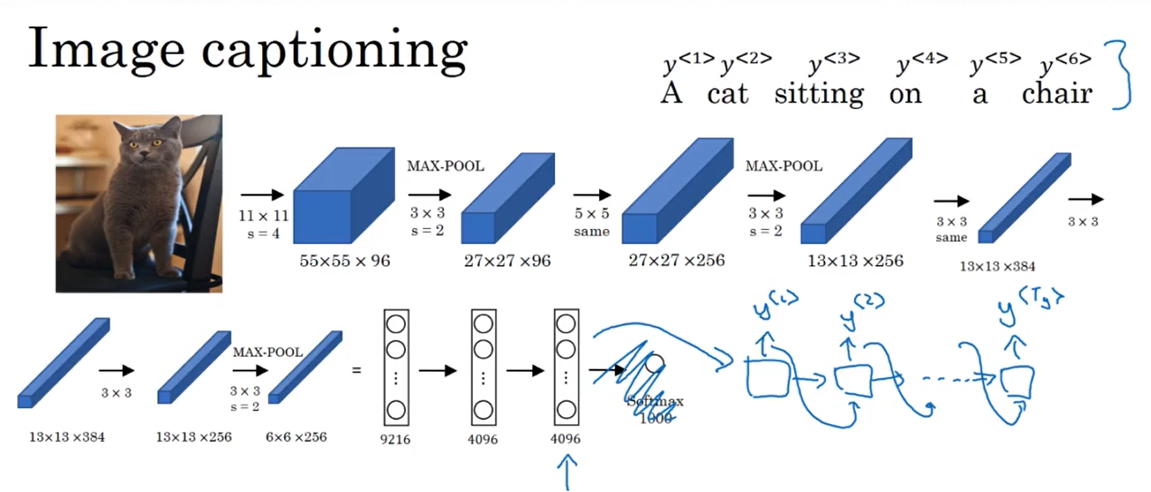

## 🐱 **Extension: Image Captioning**

* Use a **pretrained CNN** (e.g., AlexNet) to encode an image into a **feature vector**.
* Pass this vector to an **RNN decoder** to **generate a caption**, word by word.



Machine translation can be viewed as a **conditional language modeling** problem — where the goal is to model:

$$
P(\text{target sentence } y \mid \text{input sentence } x)
$$

Unlike regular language models that estimate the probability of any sequence, **machine translation** predicts the most probable target sentence **conditioned** on an input sentence.

---

## 🔄 Comparison: Language Model vs Translation Model

| Aspect       | Language Model                      | Machine Translation (Seq2Seq)                      |
| ------------ | ----------------------------------- | -------------------------------------------------- |
| Input        | None or zeros (optional prompt)     | A sentence in source language (e.g., French)       |
| Output       | Predicts next words (e.g., English) | Predicts corresponding sentence in target language |
| Type         | Unconditional                       | Conditional: $P(y \mid x)$                         |
| Architecture | Single RNN (Decoder)                | Encoder RNN + Decoder RNN                          |

---


Given French input:
**"Jane visite l’Afrique en septembre"**
You want to find the **most likely English sentence**:
**"Jane is visiting Africa in September"**

---

## 🚫 Sampling Random Outputs

Sampling randomly from $P(y \mid x)$ can lead to:

* Good results occasionally
* Awkward or wrong translations (e.g., "Her African friend welcomed Jane...")

---

## ✅ Goal: **Find the Most Likely Translation**

$$
\hat{y} = \arg\max_y P(y \mid x)
$$

But because the space of possible sentences is exponentially large (e.g., $10^4$ words ^ 10 positions), we **can’t search exhaustively**.

---

## ⚙️ Search Algorithms:

### ❌ Greedy Search:

* Picks the most probable word at each step.
* Fails to account for the **global quality** of the sentence.
* Can get stuck in suboptimal translations.

### 🧠 **Why Beam Search?**

* **Goal**: Given an input (like a French sentence or audio clip), we want to output the **most likely** translation or transcript—not a random one.
* Beam Search helps efficiently explore **multiple sentence possibilities** and select the most probable output.

---

### ⚙️ **Beam Search: Key Concepts**

| Term                 | Meaning                                                              |
| -------------------- | -------------------------------------------------------------------- |
| **Beam Width (B)**   | Number of alternative sequences kept at each decoding step           |
| **Decoder RNN**      | Generates words one at a time, using softmax to output probabilities |
| **Partial Sequence** | In-progress sentence like “Jane is” or “In September”                |

---

### 📊 **Step-by-Step Process (Beam Width = 3 Example)**

#### 🔹 **Step 1: Predict First Word**

* Use encoder to encode the given setence and pass it through Deoder.
* Use decoder to compute probabilities of all 10,000 vocab words as first word $P(y_1|x)$
* Keep top **3**: e.g., `["in", "jane", "september"]`

#### 🔹 **Step 2: Predict Second Word for Each First Word**

* For each of the 3 sequences:

  * Evaluate all 10,000 possible second words: $P(y_2 | y_1, x)$
  * Compute joint probability: $P(y_1, y_2|x) = P(y_1|x) \cdot P(y_2 | y_1, x)$
* Total: 3 × 10,000 = 30,000 sequences
* Keep top 3 sequences (e.g., `"in September"`, `"jane is"`, `"jane visits"`)

#### 🔹 **Step 3+: Extend One Word at a Time**

* Repeat: For each partial sequence (e.g., `"jane is"`), find top 10,000 continuations
* Multiply probabilities to find best full sequences
* Prune to top 3 total at each step
* Continue until `</end>` token is produced

---

### ✅ **Final Output**

* Best complete sentence found after steps (e.g., “Jane visits Africa in September”)
* This sequence has the **highest estimated conditional probability**


---

### 🔁 **Comparison to Greedy Search**

| Greedy Search                | Beam Search (B > 1)                          |
| ---------------------------- | -------------------------------------------- |
| Picks best word at each step | Explores multiple possibilities at each step |
| Faster                       | Better quality outputs                       |
| May get stuck early          | Less prone to suboptimal choices             |



### ✅ Beam Search: Purpose

Beam Search is **not required for computing probabilities** of sentences. It's a **heuristic decoding algorithm** designed to:

* Make **inference faster** and more tractable.
* **Filter out unlikely sequences** early.
* Approximate the most likely output sequence (i.e., maximize $P(y | x)$).

---

### 🧠 In Theory (Without Beam Search):

If you don’t use beam search, and instead:

* Explore **all possible output word combinations**, and
* Use your trained model to compute the probability of each full sentence via:

  $$
  P(y_1, y_2, ..., y_T | x) = \prod_{t=1}^{T} P(y_t | x, y_1, ..., y_{t-1})
  $$

Then yes — you can get the **exact probability** of any sentence. But…

---

### ⚠️ Why Not Do This in Practice?

* Suppose your vocabulary has 50,000 words.
* For a 10-word output sentence:

  $$
  50,000^{10} \text{ sequences to evaluate}
  $$
* That’s **computationally intractable** even for small sentence lengths.

---

### ✅ So Why Beam Search?

Beam search keeps only the **top $B$** (beam width) most likely partial sequences at each decoding step. It:

* Drastically reduces computation.
* Still finds **high-probability sentences** most of the time.
* Trades exactness for **speed and feasibility**.


### 🧠 **Core Problem with vanilla beam search**

* **Beam Search** selects the most likely sequence by **multiplying probabilities**:

  $$
  P(y_1, y_2, ..., y_T | x) = \prod_{t=1}^{T} P(y_t | x, y_1, ..., y_{t-1})
  $$

* Multiplying many small probabilities → **very small number**, risks **numerical underflow**.

---

### 🛠️ **Fix 1: Log Probabilities**

* Use **logarithms** to avoid underflow and improve numerical stability:

  $$
  \log P(y | x) = \sum_{t=1}^{T} \log P(y_t | x, y_{<t})
  $$

* Since `log` is monotonic, **maximizing log-probability** is equivalent to maximizing the original probability.

---

### 🛠️ **Fix 2: Length Normalization**

* Without normalization, beam search may **favor shorter sentences** (fewer small values multiplied).

* Solution: **normalize** total log-probability by sentence length:

  $$
  \frac{1}{T_y} \sum_{t=1}^{T_y} \log P(y_t | x, y_{<t})
  $$

* Or, use **soft normalization** with a hyperparameter $\alpha \in [0, 1]$:

  $$
  \frac{1}{T_y^{\alpha}} \sum_{t=1}^{T_y} \log P(y_t | x, y_{<t})
  $$

* Typical: $\alpha = 0.7$ (tunable)

---

### 🧪 **How It Works in Practice**

* Run beam search for max steps (e.g., 30 tokens)
* Collect top-k candidates at each step (beam width = B)
* Score each candidate using normalized log-probability
* **Output the sentence with highest normalized score**

---

### ⚙️ **Beam Width Trade-Off**

| Beam Width (B)         | Pros                             | Cons                                      |
| ---------------------- | -------------------------------- | ----------------------------------------- |
| Small (e.g., 1-3)      | Fast, low memory                 | May miss better sequences                 |
| Large (e.g., 10-1000+) | Higher accuracy, better coverage | Slower, memory-heavy, diminishing returns |

* **Greedy search** is beam width = 1.
* **Production systems** often use **B = 10–100**, research systems might use up to **3000**.

Here's a **summary** of the video on **error analysis in beam search**:

---

### 🎯 **Goal**

To identify whether errors in your sequence-to-sequence model are due to:

* The **RNN model** (encoder-decoder)
* Or the **beam search algorithm** (approximate search)

---

### 🧪 **Setup**

* Input sentence: `x = "Jane visite l'Afrique en septembre"`
* Human (correct) translation: `y* = "Jane visits Africa in September"`
* Model output via beam search: `ŷ = "Jane visited Africa last September"` (bad translation)

---

### 🧠 **Strategy**

Compare the model's learned probabilities:

$$
P(y^* \mid x) \quad \text{vs} \quad P(\hat{y} \mid x)
$$

There are **two cases**:

---

### ✅ **Case 1:**

$$
P(y^* \mid x) > P(\hat{y} \mid x)
$$

* The **correct translation has higher probability**, but beam search chose the wrong one.
* **Conclusion:** Beam Search is at fault.
* Fix: Consider increasing beam width or improving the search algorithm.

---

### ❌ **Case 2:**

$$
P(y^* \mid x) \leq P(\hat{y} \mid x)
$$

* The **model assigns higher probability to the wrong translation**.
* **Conclusion:** RNN model is at fault.
* Fix: Improve training (e.g. more data, regularization, architecture changes).

---

### 🔍 **Error Attribution Workflow**

1. Go through dev set examples with poor translations.
2. Compute $P(y^* \mid x)$ and $P(\hat{y} \mid x)$.
3. Label each example:

   * `B` if beam search is at fault
   * `R` if RNN model is at fault
4. Aggregate results to determine where to focus your optimization efforts.

---

### 🧮 **Note on Length Normalization**

* Long sequences tend to have lower probabilities.
* Apply **length normalization** (e.g., divide by $T^\alpha$) when comparing log probabilities.

---

### 📌 Final Takeaway

Use this method to **prioritize your engineering time**:

* If most errors are due to beam search → tweak beam width.
* If most errors are due to the model → improve RNN or training strategy.

Let me know if you'd like a visual or step-by-step example!



### 🎯 Goal:

We want to compute:

$$
P(\text{"Jane visits Africa"} \mid x) = P(y_1 = \text{"Jane"} \mid x) \cdot P(y_2 = \text{"visits"} \mid x, y_1) \cdot P(y_3 = \text{"Africa"} \mid x, y_1, y_2)
$$

Where:

* $x$ = input French sentence
* $y_1, y_2, y_3$ = "Jane", "visits", "Africa"

---

### ✅ Step-by-Step Dry Run

#### **Step 0: Encode the French sentence**

* Input French sentence is encoded by the encoder RNN → produces a **context vector** (a hidden state or a sequence of hidden states)
* Let's denote the final encoder hidden state as $h^{\text{enc}}$

---

#### **Step 1: Decoder at t = 1**

* Input: `<start>` token (or special `SOS` token)
* Hidden state: initialized from encoder $h^{\text{enc}}$
* Compute:

  $$
  P(y_1 \mid x) = \text{softmax}(W h_1 + b)
  $$

  $$
  h_1 = \text{RNN}(e_{\text{"start"}}, h^{\text{enc}})
  $$

  This gives a probability distribution over the entire vocabulary.
* Extract:

  $$
  P(y_1 = \text{"Jane"} \mid x)
  $$

---

### 🔍 What Each Term Means:

* **$E_{\langle \text{start} \rangle}$**: The **embedding vector** for the special `<start>` token.
  This is just like the embedding for any other word (e.g., "Jane"), and it's learned during training.

* **$h_{\text{enc}}$**: The **final hidden state** of the **encoder** (after processing the input sentence).
  This serves as the **initial hidden state** for the decoder.

* **RNN(...)**: The recurrence formula (could be LSTM, GRU, or vanilla RNN), which computes the first decoder hidden state $h_1$.

---

### 🔁 What's Actually Happening:

1. The `<start>` token gets converted into its **embedding vector** $E_{\langle \text{start} \rangle}$.
2. That embedding, together with $h_{\text{enc}}$, is fed into the decoder's RNN cell.
3. The RNN outputs a new hidden state $h_1$, which represents its memory **after seeing the `<start>` token**.
4. This $h_1$ is then used to **generate the first word** in the output sentence using softmax:

$$
P(y_1 \mid x) = \text{softmax}(W h_1 + b)
$$

---

### 🧠 Why This Matters:

* This is how the decoder "kicks off" the sentence generation.
* The `<start>` token signals the model to **begin** decoding.
* The encoder’s last state $h_{\text{enc}}$ **carries all the information from the input** (e.g., the French sentence).


#### **Step 2: Decoder at t = 2**

* Input: **embedding of "Jane"**
* Hidden state: carries over from t=1, so $h_1$
* Compute:

  $$
  P(y_2 \mid x, y_1) = \text{softmax}(W h_2 + b)
  $$

  where:

  $$
  h_2 = \text{RNN}(e_{\text{"Jane"}}, h_1)
  $$
* Extract:

  $$
  P(y_2 = \text{"visits"} \mid x, y_1)
  $$

---

#### **Step 3: Decoder at t = 3**

* Input: **embedding of "visits"**
* Hidden state: $h_2$
* Compute:

  $$
  P(y_3 \mid x, y_1, y_2) = \text{softmax}(W h_3 + b)
  $$
* Extract:

  $$
  P(y_3 = \text{"Africa"} \mid x, y_1, y_2)
  $$

---

### 🔁 How t=2 uses t=1?

Yes, **t=2 absolutely depends on t=1**, but **not directly in the softmax** — it depends through the **hidden state** of the RNN.

* $h_2$ = function of $h_1$ and input `"Jane"`
* $h_1$ came from decoding `<start>` token and predicted `"Jane"` — even if you **force-feed** the correct word (`"Jane"`), the decoder's internal memory (`h_1`) is still carrying forward the past.

So the dependence between steps **is captured in the hidden states**, and we **multiply probabilities only at the end** to get the final sequence probability.

---

### 🔚 Final Probability

Multiply them:

$$
P(\text{"Jane visits Africa"} \mid x) = P(y_1) \cdot P(y_2) \cdot P(y_3)
$$

In practice (due to floating-point underflow), we compute the **log** of each:

$$
\log P(\text{sequence}) = \log P(y_1) + \log P(y_2) + \log P(y_3)
$$

Yes, exactly! The step:

$$
h_1 = \text{RNN}(E_{\langle \text{start} \rangle}, h_{\text{enc}})
$$

is the **first step of the decoder** in a sequence-to-sequence model.


Sure! Let's break down the **BLEU score** (Bilingual Evaluation Understudy) — a standard metric to evaluate machine translation and other text generation tasks — **with a clear example**, step-by-step.

---

## 🧠 What is BLEU Score?

The BLEU score measures how close a **machine-generated sentence** is to one or more **human-generated reference translations**.

It focuses on:

1. **Modified n-gram precision** (do the predicted words and phrases appear in the references?)
2. **Brevity penalty** (penalizes very short predictions)

---

## 📝 Example

### ✅ Reference Sentences:

* **Ref 1**: `the cat is on the mat`
* **Ref 2**: `there is a cat on the mat`

### 🤖 Machine Translation Output (MT):

* **Candidate**: `the cat the cat on the mat`

---

## Step 1: Modified n-gram Precision

### 🔹 1-gram (unigram) Precision:

**Candidate unigrams**:

```
["the", "cat", "the", "cat", "on", "the", "mat"]
```

**Reference unigram counts** (max from either Ref 1 or Ref 2):

* "the": max 2
* "cat": max 1
* "on": max 1
* "mat": max 1

**Clipped counts** (only credit up to reference frequency):

* "the": appears 3 times → clip to 2
* "cat": 2 times → clip to 1
* "on": 1 → keep
* "mat": 1 → keep

🧮 **Precision = (2 + 1 + 1 + 1) / 7 = 5 / 7 ≈ 0.714**

---

### 🔹 2-gram (bigram) Precision:

**Candidate bigrams**:

```
["the cat", "cat the", "the cat", "cat on", "on the", "the mat"]
```

**Reference bigram counts**:
From Ref 1 and Ref 2:

* "the cat": 1
* "cat the": 0
* "cat on": 0
* "on the": 1
* "the mat": 1

**Clipped counts**:

* "the cat": appears 2 → clip to 1
* "cat the": 0 → clip to 0
* "cat on": 0 → 0
* "on the": 1 → 1
* "the mat": 1 → 1

🧮 **Precision = (1 + 0 + 0 + 1 + 1) / 6 = 3 / 6 = 0.5**

---

## Step 2: Brevity Penalty (BP)

**Reference length**:

* Ref 1: 6 words
* Ref 2: 7 words
  → Closest length: 6

**Candidate length**: 7

Since candidate is **longer**, **BP = 1**

---

## Step 3: Combine to get BLEU Score

BLEU uses up to 4-gram precision. For this example, let’s simplify to **BLEU-2** using geometric mean of unigram and bigram:

### Geometric Mean:

$$
P = \sqrt{P_1 \cdot P_2} = \sqrt{0.714 \cdot 0.5} ≈ \sqrt{0.357} ≈ 0.597
$$

### Final BLEU Score:

$$
BLEU = BP \cdot \exp \left( \sum_{n=1}^{N} w_n \cdot \log P_n \right)
$$

$$
= 1 \cdot \exp\left( \frac{1}{2} (\log 0.714 + \log 0.5) \right)
\approx \exp(-0.515) ≈ 0.597
$$

✅ **Final BLEU score ≈ 0.597**

---

## 🔑 Summary Table

| Component        | Value |
| ---------------- | ----- |
| 1-gram precision | 0.714 |
| 2-gram precision | 0.5   |
| BP               | 1     |
| BLEU (2-gram)    | 0.597 |

---

## 🧠 Intuition Recap

* **High BLEU** ⇒ Model output closely matches human references
* **Low BLEU** ⇒ Output diverges from expected references
* BLEU is **automated**, scalable, and widely used in NLP for machine translation, summarization, and image captioning.

Here’s a **summary of the video on the Attention Model** with key ideas and intuition:

---

### 🔁 **Problem with Traditional Encoder-Decoder Architecture:**

* In traditional **sequence-to-sequence** models, an **encoder RNN** reads the entire input sentence and compresses it into a single context vector (final hidden state).
* The **decoder RNN** then generates the output based **only on that vector**.
* **Issue:** This works well for short sentences, but struggles with **long sentences** (memory bottleneck).

  * BLEU score drops significantly as input sentence length increases.

---

### 🤯 **Key Insight of Attention:**

* Human translators don’t memorize the whole sentence at once. Instead, they read a bit, translate a bit, and repeat.
* The **attention mechanism mimics this** by letting the model **“look back”** at specific parts of the input sentence while generating each output word.

---

### 🧠 **How Attention Works (Intuition):**

#### Step-by-step:

1. **Input**: A sentence like `Jane visite l'Afrique en Septembre`.
2. **Encoder**: Uses a **bidirectional RNN** to compute rich feature representations (`h₁`, `h₂`, ..., `h₅`) for each input word position.
3. **Decoder**: At each step `t` (e.g. generating “Jane” or “visits”):

   * It computes **attention weights** αₜ₁, αₜ₂, ..., αₜ₅ over the input positions.
   * Each weight αₜᵢ represents **how much attention to pay** to the input word `i` when generating output word `t`.
   * Using these weights, the model computes a **context vector `Cₜ`**: a weighted sum of encoder hidden states.
   * This context vector, along with the previous hidden state and previously generated word, helps generate the next word.

---

### 🧾 **Attention Matrix:**

* For each output word `t`, we compute a row of attention weights:

  $$
  \alpha_{t1}, \alpha_{t2}, ..., \alpha_{tT_{input}}
  $$
* These rows form the **attention matrix**, showing **which input word is being focused on at each decoding step**.

---

### 🎯 **Benefits of Attention:**

* The decoder no longer relies on a single vector to represent the entire input.
* Instead, it dynamically chooses **where to look** in the input for each word it generates.
* **Result:** Better handling of long sentences and complex mappings.

---

### 💡 Final Takeaway:

The attention mechanism gives the decoder **flexible access** to the input sequence, allowing it to **focus on different words at different times**. This leads to much better performance, especially for longer or more complex sequences.

---

Here’s a **structured summary** of the attention mechanism as explained in your transcript, including the implementation steps and key intuitions:

---

### 🧠 **Goal of Attention Mechanism**

Traditional encoder-decoder RNNs struggle with **long input sequences** because they compress all input into a single vector.
**Attention** solves this by allowing the decoder to focus on **different parts of the input** while generating each output word — similar to how humans translate sentence-by-sentence.

---

### 🔧 **Components of Attention Model**

#### 1. **Encoder (Bi-directional RNN/LSTM/GRU)**

* Processes the input sequence (e.g. French sentence).
* For each time step `t′`, outputs a feature vector `a(t′)` = \[forward h; backward h].
* All `a(t′)` vectors are stored for later use by the decoder.

#### 2. **Decoder (RNN with Attention)**

* Generates each word `yₜ` of the output (e.g. English sentence).
* Uses a **context vector `cₜ`** at each decoding step, computed using attention weights.

---

### 🔁 **How Each Output Word is Generated**

At decoding step `t`:

#### Step 1: Compute **Attention Weights** `α(t, t′)`

* `t` is decoder time step (generating output word `yₜ`)
* `t′` is encoder time step (input word position)
* Compute intermediate **score** `e(t, t′)` using a small neural network:

  $$
  e(t, t′) = f(s_{t-1}, a(t′))
  $$

  where `sₜ₋₁` is previous decoder state, and `a(t′)` is encoder output at position `t′`.
* Apply softmax across all `t′` to get attention weights:

  $$
  \alpha(t, t′) = \frac{\exp(e(t, t′))}{\sum_{k} \exp(e(t, k))}
  $$

  Ensures all `α(t, t′)` sum to 1 and are positive.

#### Step 2: Compute **Context Vector** `cₜ`

$$
cₜ = \sum_{t′} \alpha(t, t′) \cdot a(t′)
$$

Weighted sum of all encoder outputs based on attention weights.

#### Step 3: Compute New Decoder State `sₜ`

$$
sₜ = \text{RNN}(s_{t-1}, [y_{t-1}, cₜ])
$$

`yₜ₋₁` is the previous word embedding.

#### Step 4: Generate Output Word `yₜ`

$$
yₜ = \text{softmax}(W[sₜ, cₜ] + b)
$$

---

### 🔄 **Repeat**

Repeat steps 1–4 for every output word until the EOS token is generated.

---

### 📌 Additional Notes

* The attention scores `e(t, t′)` are learned via **gradient descent**.
* This model allows better translation of **long sentences**, avoiding memory bottlenecks.
* Attention weights can be visualized as a heatmap showing **which input words the model is focusing on** at each output time step.


Great question! Let’s break this down precisely:

---

## 🔍 **What kind of neural network computes** `e(t, t′) = f(sₜ₋₁, a(t′))`?

### 🧠 1. **It’s a Feedforward Neural Network (also called Alignment Model)**

* Typically **one hidden layer**, because it’s evaluated at every output step for every input word — computational efficiency is important.
* Input:

  * Decoder hidden state from previous time step: `sₜ₋₁` (captures what has been translated so far)
  * Encoder hidden state (context vector for input position `t′`): `a(t′)` (captures info about input word at position `t′`)
* The network learns **how well** `a(t′)` aligns with the current decoder state `sₜ₋₁`.

### A common structure is:

$$
e(t, t′) = v^\top \tanh(W_s s_{t-1} + W_a a(t′))
$$

Where:

* `W_s`, `W_a` are learned weight matrices
* `v` is a learned vector (used to collapse the output to a scalar score)
* `tanh` adds nonlinearity

This is called the **Bahdanau Attention (Additive Attention)**.

---

## 🏷️ **What is the ground truth label for training this network?**

This small network **is not trained separately with explicit labels**. Instead:

### ✅ It's **trained jointly with the rest of the translation model** via **backpropagation**.

* The final goal of the entire model is to **maximize the probability of the correct translation**:

  $$
  \log P(y_1, y_2, ..., y_T \mid x)
  $$
* The attention weights (and thus the alignment model that computes `e(t, t′)`) are trained **indirectly** because their outputs (`cₜ`) affect the decoder’s prediction.
* So, **the ground truth** is each actual output word `yₜ` in the target sentence — and the attention alignment scores are optimized to help the model better predict that.

---

## 🔁 In other words:

* You don’t explicitly tell the model: "pay attention to word 3 in the input".
* You **only tell it the correct target word** (e.g., "Africa"), and the model **learns** which parts of the input are helpful for that prediction by adjusting `α(t, t′)` (via `e(t, t′)`).

---

## Summary Table

| Component                    | Type                            | Input                          | Output                         | Trained via                      |
| ---------------------------- | ------------------------------- | ------------------------------ | ------------------------------ | -------------------------------- |
| `f(sₜ₋₁, a(t′))`             | Feedforward NN (1 hidden layer) | Decoder state & Encoder state  | Scalar score `e(t, t′)`        | Indirectly (via prediction loss) |
| Attention weights `α(t, t′)` | Softmax over scores `e(t, t′)`  | All `e(t, t′)` for fixed `t`   | Weight distribution over input | Not explicitly supervised        |
| Final target                 | Output word `yₜ`                | Based on decoder RNN + context | Softmax prediction             | Cross-entropy loss against `yₜ`  |

---

Let me know if you’d like a **step-by-step numerical walkthrough** of how the attention weight and output are computed.


Great follow-up. Let’s clarify **what trains the encoder** in the attention-based encoder–decoder architecture:

---

## 🔄 **The Encoder is Trained Indirectly via the Final Translation Loss**

Even though the **encoder doesn't directly output a prediction**, it’s trained **as part of the end-to-end model** using **backpropagation from the decoder's loss**.

---

### 🔧 Here’s how it works step by step:

#### 1. **Input Sentence (e.g., in French)**

Say the input is:

```
x = ["Jane", "visite", "l'Afrique", "en", "septembre"]
```

#### 2. **Encoder processes it**

* A bi-directional RNN processes the input.
* At each time step `t′`, it outputs a hidden state:

  $$
  a(t′) = [\overrightarrow{h}_{t′}; \overleftarrow{h}_{t′}]
  $$
* These `a(t′)` vectors are passed **as context** to the attention mechanism.

#### 3. **Decoder uses attention over encoder outputs**

* At each output time step `t`, the decoder computes a context vector `cₜ` as a weighted sum of encoder outputs `a(t′)` (via learned attention weights `α(t, t′)`).

#### 4. **Decoder predicts the next word**

* The decoder takes:

  * Previous hidden state `sₜ₋₁`
  * Previous output word embedding `E(yₜ₋₁)`
  * Attention-derived context vector `cₜ`
* And outputs a prediction:

  $$
  \hat{y}_t = \text{softmax}(W[s_{t}, c_t] + b)
  $$
* The model compares this predicted word `\hat{y}_t` with the **ground truth word** `yₜ` using **cross-entropy loss**.

#### 5. **Backpropagation updates everything**

* That loss gets backpropagated **through the decoder**, **through the attention mechanism**, and then **into the encoder**.
* So the encoder’s parameters (weights in the RNN or LSTM/GRU) are **updated to help produce better `a(t′)` vectors**, which lead to better context vectors `cₜ`, and thus better predictions.

---

## 🔁 Summary

| Component               | Trained On                                | Training Signal Comes From                              |
| ----------------------- | ----------------------------------------- | ------------------------------------------------------- |
| **Encoder**             | Input sentence                            | **Backpropagated error from decoder's prediction loss** |
| **Decoder**             | Ground truth output sentence              | Cross-entropy loss on predicted vs actual word          |
| **Attention Mechanism** | Weights (`α(t, t′)`)                      | Learned to focus where prediction is most accurate      |
| **Overall**             | Pair of (input sentence, target sentence) | Supervised learning with sentence pairs                 |

So basically we've 3 neural nets 

1. Encoder 
2. Small neural net for alpha 
3. Decoder network 

All the params are trained with the backpropagation from decoder network


### Audio Data

Speech Recognition 

Here’s a **summary** of the key points from the lecture on **applying sequence-to-sequence models to speech recognition**:

---

### 🎯 **Speech Recognition Task**

* **Input**: Audio waveform (changes in air pressure over time).
* **Output**: Text transcript (e.g., "the quick brown fox").
* Audio is often preprocessed into a **spectrogram** (time × frequency representation), similar to how the human ear detects frequency intensities.

---

### 🔄 **Traditional vs. Deep Learning Approaches**

* **Traditional systems** relied on **phonemes**: manually defined sound units like "th", "k", etc.
* **End-to-End Deep Learning** (e.g., RNN-based models) has **replaced phonemes**, learning directly from **audio → transcript**, without hand-crafted intermediate steps.

---

### 📈 **Data Requirements**

* **Academic datasets**: \~300–3,000 hours of transcribed audio.
* **Commercial systems**: Often trained on **10,000+ hours**, sometimes **over 100,000 hours**.
* The combination of **large datasets** and **deep learning** has significantly improved speech recognition performance.

---

### ⚙️ **Two Main Deep Learning Approaches**

#### 1. **Attention-Based Models**

* Use encoder-decoder with **attention mechanism** to align audio segments with corresponding output text.
* Similar to machine translation — pays attention to parts of the input audio when generating each character or word.

#### 2. **CTC (Connectionist Temporal Classification)**

* Allows **many input time steps (e.g., 1000)** to be mapped to a **shorter output sequence (e.g., 19 characters)**.
* Output includes **repeated characters** and **special “blank” tokens** (denoted `_`), which are collapsed:

  * Example raw output: `ttt_h_eee___ qqq__` → Collapses to: `the q`
* Invented by **Alex Graves et al.**, used in systems like **DeepSpeech**.

---

### ✅ **CTC Rules**

* Collapse **repeated characters** not separated by blanks.
* Remove **blanks (\_)**.
* Allows model to output long sequences that still encode short text by using blank and repeated outputs.


### ✅ **CTC-based Speech Recognition: Step-by-Step**

#### **1. Slice audio into short frames (e.g., every 10ms, not 1ms)**

* Audio is typically divided into frames every **10–20ms** (e.g., 100Hz sampling).
* So, a **1-second** clip → **100 frames** if using 10ms slices.

#### **2. Convert each frame to a feature vector**

* Each frame is processed into a **feature vector** (e.g., using Mel-Frequency Cepstral Coefficients (MFCC), spectrograms, or filter banks).
* Now you have a sequence like:
  `[x₁, x₂, ..., x₁₀₀]` where each `xᵢ` is a feature vector.

#### **3. Feed the sequence to a neural network (RNN, BiLSTM, etc.)**

* This sequence is input to a **recurrent** or **convolutional** neural network.
* The model outputs a **distribution over characters** (e.g., a-z, space, blank `␣`) **for each time step**.

#### **4. Model predicts character at each time step**

* Example output:
  `[t, t, ␣, h, h, e, ␣, ␣, q, q, ␣, u, i, c, ␣, ␣, k, ␣]`
  (many repetitions and blank tokens)

#### **5. Apply CTC decoding**

* **Collapse repeated characters**:
  `t, t → t`, `h, h → h`, etc. (but only if not separated by blanks)
* **Remove blanks (`␣`)**:
  `t, h, e, q, u, i, c, k`
* Final prediction:
  **"the quick"**

---

### 🧠 Notes:

* **Blank token** (`␣`) is special — it lets the model separate repeated characters (e.g., `book` vs `boook`).
* No need to align audio frames to characters during training — **CTC loss learns this alignment automatically**.
* CTC is useful when input length ≫ output length (common in audio).


Sure! Let's walk through what **training data** looks like for a **speech recognition system using CTC loss**.

---

### 🎯 Goal

Let’s say you have:

* **Audio clip**: someone saying `"cat"`
* **Ground truth label**: `"cat"` (just the text)

---

### 🧾 Step-by-Step: How the training data looks

#### 1. **Audio Input (X)**

The audio clip is converted into **features** — typically **spectrogram slices** or **MFCCs** (Mel-Frequency Cepstral Coefficients).

Example (simplified):

* The model receives a sequence of feature vectors over time:

```python
X = [x₁, x₂, x₃, ..., x₁₀₀]
# 100 time steps (e.g., for a 1-second clip sampled at 100 Hz)
```

Each `xᵢ` might be a 13- or 40-dimensional vector representing sound features at that moment.

---

#### 2. **Label Sequence (Y)**

This is the actual **target transcription**:

```python
Y = ['c', 'a', 't']
```

Note: There's **no alignment** between `xᵢ` and characters in `Y`. The model doesn’t know whether `'c'` should be output at `x₁₀` or `x₁₅`.

---

#### 3. **CTC Loss handles alignment**

CTC allows the model to emit:

* Characters from the vocabulary (`a`, `b`, ..., `z`)
* A special **blank token** (`_`) to indicate no character is emitted at that time step

---

### 🔧 How training works

During training:

* The model outputs a **probability distribution** at each time step over all possible characters + blank:

```python
Output at x₁: {'_': 0.4, 'c': 0.3, 'a': 0.1, ..., 'z': 0.01}
Output at x₂: {'_': 0.5, 'c': 0.2, 'a': 0.15, ..., 'z': 0.01}
...
Output at x₁₀₀: {'_': 0.8, 't': 0.1, ..., 'z': 0.01}
```

* CTC **collapses** the predictions:

  * Repeats → one char
  * Blanks → removed

For example, if the raw predictions are:

```
['_', 'c', 'c', '_', 'a', '_', 't', 't', '_']
```

After collapsing:

```
→ 'cat'
```

If this matches the ground truth `'cat'`, the loss will be low — if not, the model adjusts weights via backpropagation.

---

### ✅ Summary of training data format

| Component      | Description                                |
| -------------- | ------------------------------------------ |
| **Input (X)**  | Sequence of audio feature vectors          |
| **Target (Y)** | Character sequence (e.g., `['c','a','t']`) |
| **Alignment**  | Not needed – handled by CTC loss           |

Great question — and this gets to the heart of how **sequence models like RNNs, GRUs, or LSTMs** (and modern variants like Transformers) process time series data.

---

### 🔄 Does the model process `x₁`, `x₂`, ... individually?

**No**, not in isolation.

---

### ✅ What Actually Happens: Batched Sequential Processing

You **input the entire sequence** `[x₁, x₂, ..., x₁₀₀]` at once as a matrix:

```python
X = [
  x₁ᵀ,
  x₂ᵀ,
  ...,
  x₁₀₀ᵀ
]  # Shape: (100, d), where d is feature dimension
```

Then, this matrix is processed sequentially by the model (say a BiLSTM), which **keeps track of past (and future, if bidirectional) context** through hidden states.

---

### 🧠 Internally:

* At **time step t**, the model processes `xₜ` **using knowledge from previous steps** via the hidden state:

  * For LSTM: uses `(hₜ₋₁, cₜ₋₁)` to process `xₜ`
  * For Transformer: uses attention across all `x₁` to `xₜ`

---

### 🔁 Output

At each step, it gives a **softmax distribution** over possible output characters:

```python
yₜ = softmax(W · hₜ + b)  # Character probabilities at time step t
```

This is repeated for all time steps to give a full output matrix of shape:

```
(100, |V|)  →  100 time steps × vocabulary size
```

Where `|V|` includes characters **+ the blank symbol** for CTC.

---

### 🧠 Summary

| Step    | Description                                                 |
| ------- | ----------------------------------------------------------- |
| Input   | Full matrix: shape = (time steps, feature dim)              |
| Process | RNN/LSTM processes sequentially using memory (hidden state) |
| Output  | Softmax over characters + blank per time step               |

So while the softmax output is **per time step**, the model sees the **entire sequence** (not isolated vectors). This gives it temporal context to make more accurate predictions.

Would you like a simple NumPy or PyTorch mock example to visualize this?




### ⚡ Transformers

* **Transformers** are a **parallelizable** architecture that processes all words in a sentence **simultaneously**.
* Developed in the **“Attention is All You Need”** paper by Vaswani et al.
* Combines:

  * **Attention-based representation** (especially *self-attention*)
  * **CNN-style parallel computation** (not actual CNNs, but a similar parallel spirit)

---

### 🔑 Core Concepts Introduced:

1. **Self-Attention**:

   * Computes **contextualized word representations** in parallel.
   * For a sentence with 5 words → generates 5 rich vectors: A₁, A₂, ..., A₅
   * Each vector "attends" to other words in the sentence.

2. **Multi-Head Attention**:

   * Like running **self-attention multiple times** with different projections.
   * Captures **different types of relationships** between words.

##  Self-Attention?

Self-attention allows the model to compute a **context-aware representation** of each word by **looking at other words in the same sentence**. This is central to how Transformers understand language.

---

## 🔍 Goal

Given a sentence like:

> *Jane visite l'Afrique en septembre*

We want to compute **a new vector for each word** (A₁ through A₅), where each vector captures **the meaning of that word in context**.

---

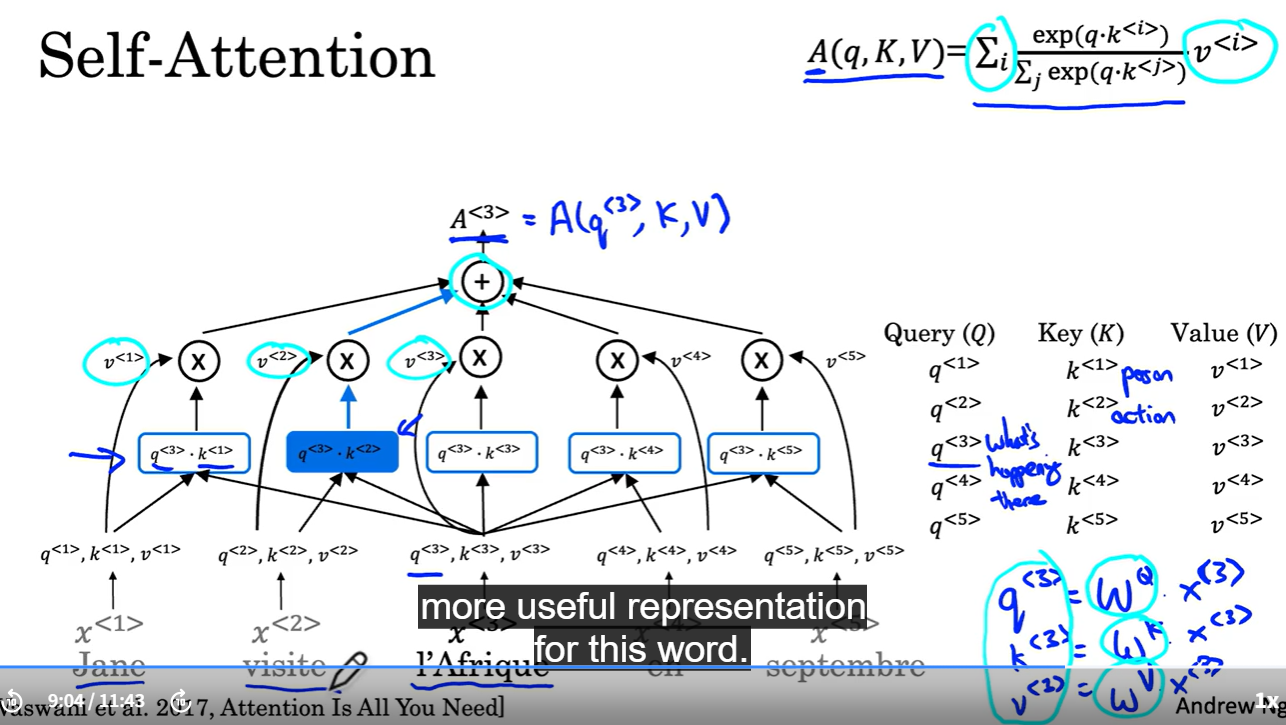

## 📊 Key Concepts: Query, Key, and Value

For each word embedding `Xᵢ`:

* `Qᵢ = W_Q * Xᵢ` → **Query**: What am I looking for?
* `Kᵢ = W_K * Xᵢ` → **Key**: What information do I offer?
* `Vᵢ = W_V * Xᵢ` → **Value**: What representation should I pass along?

These are **learned projections** from the original word embedding.

---

## ⚙️ Example: Computing A₃ for "l'Afrique"

1. Compute `Q₃` for “l'Afrique”.
2. Compare `Q₃` to all `Kⱼ` (1 through 5) using **dot products** → how relevant is each word to “l’Afrique”?
3. Pass the dot products through **softmax** → gives weights (attention scores).
4. Multiply each score with the corresponding `Vⱼ`.
5. **Sum** these to get A₃ — the new vector for “l’Afrique”.

This gives a **dynamic**, context-dependent vector for the word.

---

## 📐 Final Attention Formula

For all words at once, the attention formula is:

$$
\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^\top}{\sqrt{d_k}}\right) V
$$

Where:

* $Q, K, V$ are matrices of all queries, keys, and values.
* $\frac{1}{\sqrt{d_k}}$ is a scaling factor to prevent large dot products.

This is called **scaled dot-product attention**.

---

## ✅ Why This Works

Instead of a **fixed embedding** for "l’Afrique", we now get a **richer vector** that knows:

> It’s being talked about as a travel destination, because of the word “visite”.

This way, the **meaning of each word shifts with context** — enabling nuanced language understanding.

## Self Attention

### **Sentence:**

> “Dwijraj visits London”

---

### ✅ **1. Word Embeddings**

Each word is converted to a **vector of dimension `d_model`**, say 512.

So you get:

* `X₁ = E("Dwijraj")`
* `X₂ = E("visits")`
* `X₃ = E("London")`

This forms the input matrix `X ∈ ℝ^(3 × d_model)`

---

### ✅ **2. Compute Q, K, V for each word**

We apply **learned weight matrices**:

* `Q₁ = W_Q × X₁`
* `K₁ = W_K × X₁`
* `V₁ = W_V × X₁`
  (and similarly for X₂ and X₃)

Now you have:

* Queries: `Q₁`, `Q₂`, `Q₃`
* Keys: `K₁`, `K₂`, `K₃`
* Values: `V₁`, `V₂`, `V₃`

---

### ✅ **3. Choose word to compute attention for**

Let’s compute **attention output for the 1st word** = “Dwijraj”.

So we use `Q₁`.

---

### ✅ **4. Compute similarity scores (dot product of Q₁ with all Kᵢ)**

We calculate:

* `score₁ = Q₁ • K₁`
* `score₂ = Q₁ • K₂`
* `score₃ = Q₁ • K₃`

These are the **raw attention scores** → measure of relevance of each word **to "Dwijraj"**.

---

### ✅ **5. Softmax over scores**

Apply softmax to these 3 scores to get attention weights:

```
α₁ = softmax(score₁, score₂, score₃)
    = [α₁₁, α₁₂, α₁₃]
```

Now:

* α₁₁ → attention paid to “Dwijraj”
* α₁₂ → attention paid to “visits”
* α₁₃ → attention paid to “London”

---

### ✅ **6. Weighted sum of values using attention weights**

Compute:

```
A₁ = α₁₁·V₁ + α₁₂·V₂ + α₁₃·V₃
```

This is the **attention output vector A₁** for the word “Dwijraj”.

---

### ✅ **7. Repeat for other words**

Repeat the same steps using:

* `Q₂` to compute A₂ (for "visits")
* `Q₃` to compute A₃ (for "London")

---

### ✅ **Final Output of Self-Attention Layer**

* `[A₁, A₂, A₃]` → 3 vectors
* Together they form a matrix of shape `3 × d_model`

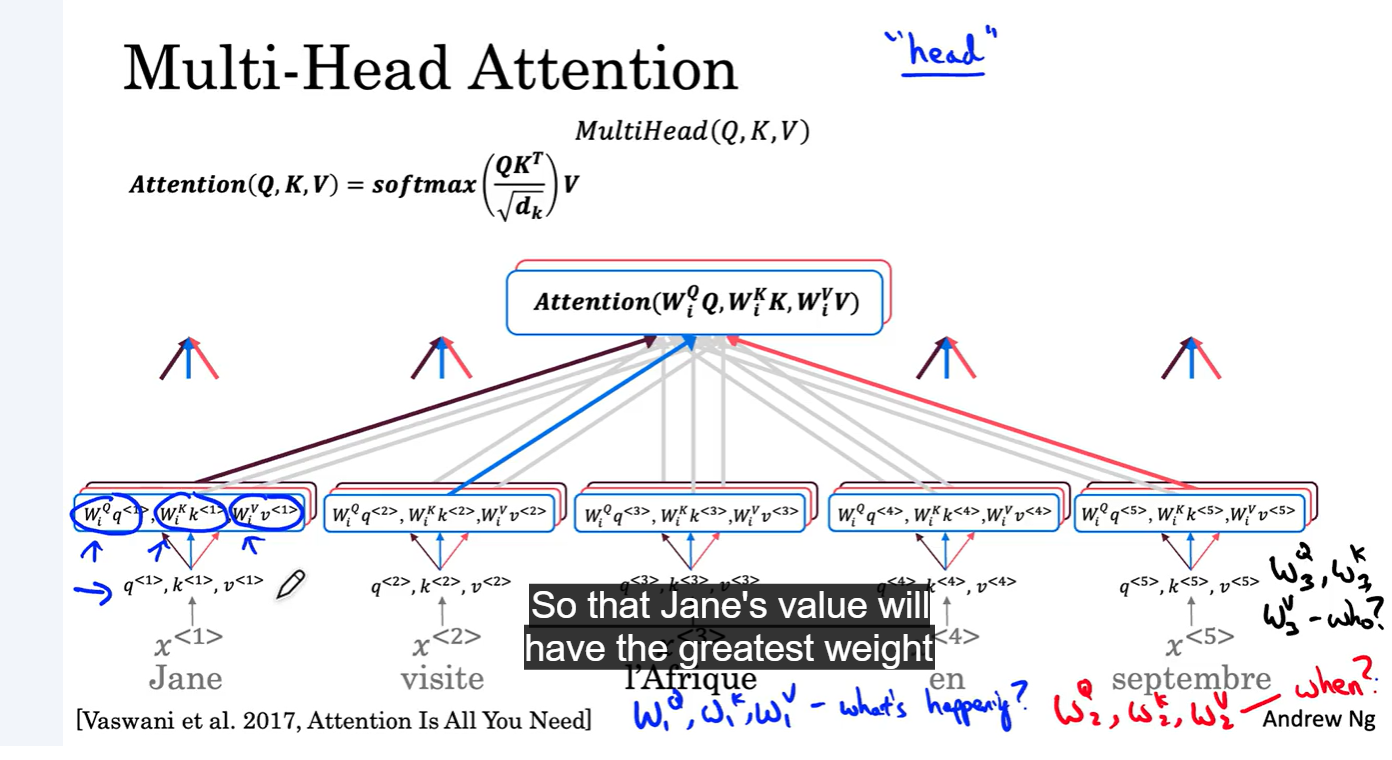

Here's a **summary of Multi-Head Attention** from the video:

---

### 🧠 **Core Idea:**

Multi-head attention = running **self-attention multiple times in parallel**, each time with **different learnable weight matrices**, allowing the model to learn **different perspectives** or “questions” about the same input.

---

### 🧱 **Structure:**

#### 1. **Input:**

You begin with:

* Word embeddings → Form matrix `X`
* From `X`, derive Query (`Q`), Key (`K`), and Value (`V`) matrices.

#### 2. **Each Head:**

For each of the **H heads**:

* You apply a different set of learned weight matrices:

  ```
  Qᵢ = X · W_Q⁽ⁱ⁾
  Kᵢ = X · W_K⁽ⁱ⁾
  Vᵢ = X · W_V⁽ⁱ⁾
  ```
* Use these to compute self-attention:

  ```
  Attention(Qᵢ, Kᵢ, Vᵢ) = softmax(Qᵢ·Kᵢᵀ / √d_k) · Vᵢ
  ```

Each head may "ask" a different type of question:

* Head 1 → "What is happening?"
* Head 2 → "When is it happening?"
* Head 3 → "Who is involved?"

---

### 🧵 **Concatenation and Output:**

* All `H` heads produce their attention outputs (shape: `seq_len × d_head`)
* Concatenate all `H` outputs → final shape becomes `seq_len × (H × d_head)`
* Pass through a final projection matrix `W₀` to bring it back to original `d_model` size:

  ```
  MultiHead(Q, K, V) = Concat(head₁, ..., head_H) · W₀
  ```

---

### ⚡ **Parallel Computation:**

Though conceptually described as a **for-loop**, all heads can be computed **in parallel** since they are **independent** of each other.

---

### 🔁 **Why Multi-Head?**

* Instead of a single attention focus (like in standard attention),
* Multi-head allows the model to **focus on multiple aspects** of the context **simultaneously**.

---

### 🧩 **Final Result:**

Each word gets a **richer, more nuanced vector representation** based on **multiple types of attention**.


Exactly — you're spot on! ✅

### Here's a clear breakdown:

#### 🧠 Multi-Head Self-Attention in Transformers

* All **heads share the same input** → the matrix `X`, which contains the **word embeddings** of the input sequence.

  ```
  X = [x₁, x₂, ..., xₙ]ᵀ
  ```

* For **each head**, we apply **independent linear transformations** to X:

  ```
  Head i:
    Qᵢ = X · W_qᵢ
    Kᵢ = X · W_kᵢ
    Vᵢ = X · W_vᵢ
  ```

* Each head performs its **own self-attention computation** independently:

  ```
  Attentionᵢ = softmax(Qᵢ · Kᵢᵀ / √dₖ) · Vᵢ
  ```

* After all heads compute their outputs, we **concatenate** their results:

  ```
  MultiHeadOutput = Concat(Attention₁, Attention₂, ..., Attentionₕ) · W_o
  ```

---

### 🔄 Why this design?

* It allows the model to **"look at" the input sequence from multiple perspectives**:

  * One head might focus on **syntax**
  * Another might focus on **semantic role**
  * Another might track **long-range dependencies**
* And since each head has **its own learnable projection matrices**, it learns **specialized attention patterns** over time.

---

### 🔗 Key Takeaway:

> ✅ Yes — **all heads are completely independent of each other**,
> ✅ and all of them operate directly on the **same input matrix X** (word embeddings or hidden representations).


## Transformer Network

Here’s a **concise and clear summary** of the entire **Transformer architecture** based on the video:

---

## 🔄 Overview of Transformer Architecture (for Machine Translation)

### 🎯 Goal:

Translate input sentence (e.g., French) → output sentence (e.g., English) using **attention-based parallel processing**.

---

## 1. **Input Embedding + Positional Encoding**

* Each input word (e.g., *Jane, visite...*) is converted into a **word embedding vector**.
* Add **positional encoding** (using sine/cosine functions) to preserve word order.

  * Example:
    For embedding `X` and position encoding `P`:
    `Z = X + P`

---

## 2. **Encoder Stack** (Repeated *n* times, typically *n=6*)

Each encoder block contains:

1. **Multi-head self-attention**

   * Input: All words in parallel.
   * Attention between all words to capture global relationships.
2. **Feedforward network**
3. **Add & Norm (residual connection + layer normalization)**

🔁 Output of one encoder block is input to the next. Final encoder output holds contextual embeddings.

---

## 3. **Decoder Stack** (Also repeated *n=6* times)

Each decoder block has:

1. **Masked Multi-head self-attention**

   * Looks only at previous tokens (prevents cheating during training).
2. **Encoder-Decoder Attention**

   * **Query** from decoder so far.
   * **Key/Value** from encoder output.
   * Helps decoder attend to relevant encoder tokens.
3. **Feedforward network**
4. **Add & Norm**

The decoder predicts one word at a time, using previously generated words.

---

## 4. **Output Prediction**

* Final decoder output goes through:

  1. **Linear layer**
  2. **Softmax layer** → predicts next word.

---

## 🧠 Training vs Inference

### During Inference:

* Start with `<SOS>` (start-of-sequence)
* Predict next word → Feed it back → Repeat until `<EOS>` (end-of-sequence)

### During Training:

* Use **entire correct output sentence**.
* Apply **masking** in self-attention to prevent using "future" words.

---

## ✅ Key Enhancements

* **Positional Encoding**: Adds order to input
* **Multi-head Attention**: Learns multiple patterns simultaneously
* **Add & Norm**: Helps gradient flow and speeds up training
* **Masked Attention**: Ensures proper training of decoder

---

## 🔚 Final Notes

* The original paper “**Attention Is All You Need**” introduced this structure.
* Later models like **BERT**, **GPT**, **DistilBERT** build upon this architecture.


Great! Let’s now **dive deep into the Transformer architecture** and explain every component **step by step** with the complete flow of how it works, both during **training** and **inference** (prediction time).

---

## 🔄 Transformer: Full Architecture Breakdown

### 📘 Context

The Transformer was introduced in the 2017 paper **“Attention Is All You Need”**. Unlike RNNs and LSTMs, it processes sequences **in parallel**, enabling **faster training** and **better handling of long-term dependencies** using **self-attention**.

---

## 🧱 Key Components:

1. Input Embedding + Positional Encoding
2. Encoder Stack (x N layers)
3. Decoder Stack (x N layers)
4. Output Softmax Layer

---

## STEP 1: 🔤 **Input Embedding + Positional Encoding**

* Each word is mapped to a vector (via a learned **embedding matrix**).
* Since the model doesn’t process sequentially, we must add **positional encoding** to indicate word positions.

### ➕ Positional Encoding

Adds position information using sine & cosine functions:

* If embedding size = `d`, then position encoding vector is also size `d`.
* For position `pos` and dimension `i`:

  $$
  PE_{(pos, 2i)} = \sin\left(\frac{pos}{10000^{2i/d}}\right), \quad
  PE_{(pos, 2i+1)} = \cos\left(\frac{pos}{10000^{2i/d}}\right)
  $$

> These produce unique, continuous values for each position that can be **added** to word embeddings.

---

## STEP 2: 🎛️ **Encoder Block**

### Structure of Each Encoder Layer:

* **Multi-head self-attention**
* **Feedforward layer (position-wise)**
* **Add & Layer Norm** (residual connections)

### 🧠 Self-Attention (per word):

For each word’s embedding vector `xᵢ`, compute:

* Query (Q) = Wₚ \* xᵢ
* Key (K) = Wₖ \* xᵢ
* Value (V) = Wᵥ \* xᵢ
  (All `W`s are learnable weight matrices)

For attention:

$$
\text{Attention}(Q, K, V) = \text{softmax} \left( \frac{QK^T}{\sqrt{d_k}} \right) V
$$

This gives **contextualized representations** for each word.

### 🔄 Multi-head Attention:

Repeat attention calculation **H times**, with different learnable matrices per head. Then:

* Concatenate all outputs
* Multiply with final matrix `W₀`
  → Get final attention output.

### 🛠 Feedforward Layer:

Applies to each word position separately:

$$
\text{FF}(x) = \text{ReLU}(xW_1 + b_1)W_2 + b_2
$$

### ➕ Add & Norm:

Apply residual connection + layer norm after attention and feedforward:

$$
\text{LayerNorm}(x + \text{Sublayer}(x))
$$

### 🔁 Stack this encoder block **n times** (typically `n = 6`).

---

## STEP 3: 🧠 **Decoder Block**

Same structure as encoder with **3 key differences**:

1. **Masked multi-head self-attention**

   * Prevents decoder from “seeing” future words during training
   * Masked by setting attention scores for future tokens to `-inf` before softmax

2. **Encoder-Decoder Attention**

   * Q from decoder
   * K, V from encoder output (attend over encoded input)

3. **Final Feedforward + Add & Norm**

This block is also **repeated n times** (again typically 6).

---

## STEP 4: 🔤 **Output Softmax Layer**

* Final decoder output is passed to a **linear + softmax layer**:

  $$
  \hat{y}_t = \text{softmax}(W_{out} \cdot \text{decoder\_output}_t)
  $$
* Predicts next word in vocabulary.

---

## 🤖 Training vs Inference

### During Training:

* Input: Source sentence (e.g., French)
* Target: Ground truth sentence (e.g., English)
* Decoder uses **full correct sentence** with masking applied to ensure **left-to-right** generation.

### During Inference:

* Start with `<SOS>`
* Predict word by word: Feed predicted word back into decoder
* Stop when `<EOS>` is generated

---

## ✅ Additional Tricks

### 1. **Masked Multi-head Attention**

* During training, masks out future tokens
* Ensures model only uses past context

### 2. **Add & Norm (Residuals)**

* Improves gradient flow
* Similar to ResNets

### 3. **Layer Normalization**

* Normalizes activations across features

---

## 🚀 Benefits of Transformers

| Feature              | Benefit                          |
| -------------------- | -------------------------------- |
| Self-attention       | Captures long-range dependencies |
| Parallel computation | Faster training than RNNs        |
| Positional encoding  | Maintains sequence order         |
| Multi-head attention | Multiple perspectives per word   |
| Residuals + Norm     | Stable, deep architectures       |

---

## 📚 Example Flow (Translation)

Given sentence:
**Input**: “Jane visite l’Afrique en septembre”
**Output**: “Jane visits Africa in September”

Steps:

1. Input sentence → Embedding + Position → Encoder Stack
2. Decoder starts with `<SOS>`
3. Predict “Jane”, then feed it back
4. Predict “visits” → “Africa” → “in” → “September” → `<EOS>`
